# Keras Tutorial: Seq2Seq Machine Translation (and a Mystery Language)

This notebook implements a **vanilla encoder–decoder LSTM seq2seq model** for machine translation.
It focuses on the basic ingredients of seq2seq without attention: how to represent sentences,
train a model with teacher forcing, and evaluate its translations.

We work with a small multi-parallel corpus containing sentences in:

- Danish  
- English  
- German  
- Finnish  
- Spanish  
- A “mystery” coded language

This data was adapted from the [European Parliament Proceedings Parallel Corpus 1996-2011](https://www.statmt.org/europarl/).

Broadly speaking, the mystery stream is produced by applying a **lossy letter-level code** to one of the real languages.
Our goal is to:

- Build a high-quality seq2seq model for English → Spanish.
- Reuse the same architecture to translate from each candidate language into the mystery stream.
- Compare how well each candidate fits, using BLEU and qualitative inspection.

This notebook has two main goals:

1. **Build and inspect a vanilla seq2seq translation model (English → Spanish)**  
   - Load and preprocess the English → Spanish parallel data into a `TranslationDataset`.  
   - Convert the datasets into padded NumPy arrays that we can feed into our Keras encoder–decoder model.  
   - Implement an encoder–decoder LSTM without any extra mechanisms on top.  
   - Train the model with teacher forcing, dropout, and early stopping (with and without `<UNK>` filtering).  

2. **Use seq2seq translation models to identify the mystery language**  
   - For each candidate source language (Danish, English, German, Finnish, Spanish),  
     train the same seq2seq architecture to translate from that language into the mystery language.  
   - Compare their BLEU scores on the mystery-language test set to see which fits best.  
   - Use the results (plus some linguistic reasoning) to argue which real-world language is
     most likely hiding behind the mystery encoding.

By the end of the notebook, you will have:

- A working encoder–decoder seq2seq translation model for English → Spanish.  
- Plots of training and validation loss for multiple language pairs.  
- BLEU-based evidence of what the “mystery” language is a systematically encoded version of.

## TO RUN THIS NOTEBOOK YOU MUST MAKE THE DATA FILES AVAILABLE

For this notebook we use pre-tokenized parallel sentences stored in three
pickled dictionaries:

- `mt_train_sentences.pkl`  
- `mt_val_sentences.pkl`  
- `mt_test_sentences.pkl`

Each file is a Python `dict` mapping language names to lists of tokenized
sentences, for example:

- `"english"` → list of English sentences (each as a list of tokens)  
- `"spanish"` → list of Spanish sentences  
- `"danish"`, `"german"`, `"finnish"`, `"mystery"`, etc.

> **Folder structure:**  
> Put all three `.pkl` files into a folder called `data` in the same directory
> as this notebook:
>
> ```text
> your_project/
> ├── translation_attention_keras.ipynb
> └── data/
>     ├── mt_train_sentences.pkl
>     ├── mt_val_sentences.pkl
>     └── mt_test_sentences.pkl
> ```
>
> The loading code expects paths like:
>
> ```python
> with open("data/mt_train_sentences.pkl", "rb") as f:
>     train_dict = pickle.load(f)
> ```

Once these files are in place, we can:

- Load the three dictionaries for train/validation/test.
- Build vocabularies over the chosen source and target languages.
- Wrap the tokenized sentence pairs in a `TranslationDataset` and convert them
  into padded NumPy arrays that will be fed into our Keras seq2seq model.



# 1. Foundations

## What is a seq2seq model?

In this notebook we use a classic **encoder–decoder “sequence-to-sequence” (seq2seq) model** built from LSTMs.

At a high level, a seq2seq model:

- Uses an **encoder** network to read the entire source sentence and compress it into a fixed-size hidden state.
- Uses a **decoder** network to generate the target sentence one token at a time.
- Passes information from encoder to decoder via the encoder’s final hidden (and cell) state.
- Is trained with **teacher forcing**: during training, the decoder sees the *true* previous target token as input.

More concretely:

1. The encoder LSTM reads a padded sequence of source token IDs of shape `(batch_size, T_enc)` and produces:
   - A sequence of encoder hidden states of shape `(batch_size, T_enc, hidden_size)`, and
   - A final hidden and cell state of shape `(batch_size, hidden_size)`.
2. The decoder LSTM starts from the encoder’s final hidden and cell state and takes as input a padded sequence of
   previous target tokens (shifted right). It outputs:
   - A sequence of decoder hidden states of shape `(batch_size, T_dec, hidden_size)`.
3. A final linear layer maps each decoder hidden state to a vector of logits over the target vocabulary, so we can
   predict the most likely next token at each time step.

In more advanced variants (covered in a separate notebook) you can augment this basic architecture with mechanisms
that let the decoder “look back” at different parts of the encoder sequence. In this notebook, however,
we stick to the simplest encoder–decoder design to keep the focus on the core seq2seq ideas.


## Does translation direction matter (A→B vs B→A)?

Even when we use the same architecture and the same number of parallel sentences, we should *not* expect a seq2seq model to perform identically in both directions (A→B vs B→A). Natural languages are not in a neat one-to-one correspondence: vocabulary sizes differ, phrases of length $N$ in one language may map to phrases of length $M$ in the other, and some semantic distinctions that are lexicalized in one language are collapsed or paraphrased in the other.

This often makes one direction more “lossy” than the other. For example, in Spanish the word `prima` means “female cousin.” In real usage, translating to English, this would usually just become `cousin`, because explicitly saying “female cousin” (“I went for a walk with my female cousin”) sounds marked or awkward. A seq2seq model trained on actual usage would likely learn the more natural `prima → cousin` mapping. But now, going back from English to Spanish, the model has to choose between `prima` (female) and `primo` (male), even though that gender information was thrown away when we went into English.

In the other direction, consider the English phrasal verb `look forward to`, which has no single-word equivalent in Spanish. A very common translation is `esperar`, which can mean “to wait” or “to hope,” so “I’m looking forward to seeing you” often becomes something like “espero verte.” Information is lost: “looking forward” implies positive anticipation and high likelihood, not just desire. Testing this in Google Translate is interesting, as the translations reach a sort of equilibrium where the phrase is mutually translatable after the information loss has occurred. In this example in Google Translate, `I look forward to seeing you` → `Espero verte pronto` → `I hope to see you soon`.

These examples illustrate the general point: because languages differ in how granular or coarse their lexical choices are, and because some semantic distinctions cannot be perfectly preserved, the A→B mapping and the B→A mapping do not have the same difficulty. As a result, we should not expect a seq2seq model to achieve the same performance range in both directions, even on the same parallel corpus.

## What happens if we scramble all the characters?

Consider a word-level seq2seq model trained on a parallel corpus. What happens if we systematically scramble the characters in the source language before tokenization?

### **Case 1: Scramble characters, but never introduce whitespace**

In the first scenario, we replace every distinct non-whitespace character in the source language with a different distinct non-whitespace character. For example, `h → s`, `e → w`, `l → o`, `o → x`, so that `"hello"` becomes `"swoox"`. The mapping is one-to-one and never produces spaces.

From the model’s perspective, nothing fundamental has changed. It still sees a sequence of *word tokens* separated by whitespace, and the vocabulary is the same size—each original word just has a different spelling. During training, the model can learn embeddings for `"swoox"` that play the same role `"hello"` used to play. Since translation operates on a per-word basis and we haven’t created new word boundaries, we should expect performance to be essentially unchanged.

Another way to see this is to notice that this is just a simple substitution cipher at the character level (like a Caesar cipher). Frequency analysis can recover the original text because the distribution of words and their co-occurrences is untouched. All we’ve done is rename the characters; the underlying sentences and their meanings are the same, so a word-level seq2seq model can, in principle, learn exactly the same mapping.

### **Case 2: Scramble characters and allow whitespace**

In the second scenario, we again replace every distinct character with a different distinct character, but now the replacement may include whitespace. That is, some letters might be turned into spaces. The mapping is still one-to-one at the character level, but now a single original word can be transformed into multiple whitespace-separated chunks.

If the language uses spaces as word delimiters (like English, Spanish, etc.), this is a big problem: tokenization changes. A single word in the original corpus can become several “words” in the scrambled corpus, and the one-to-one correspondence between source words and their scrambled forms is broken. For example, imagine the letter `p` is mapped to a space:

- Original: `I own a campsite`
- After mapping `p → space` (before we scramble the other characters):  
  `I own a cam site`  
  Now `campsite` has been split into `cam` and `site`, which clearly has a different meaning.
- After scrambling the remaining letters into other non-whitespace symbols, we still see that the tokenization pattern differs (e.g., `O gcf a ead lomt` vs something like `O gcf a eadhlomt` if no space had been introduced).

For a space-delimited language, this means:

- The model now has to learn mappings from longer, more fragmented source sequences to target sentences.
- The neat word-level correspondences in the original parallel data are replaced by more complex many-token-to-one-word mappings.
- Semantic cues that were neatly packaged in single word tokens are now scattered across multiple tokens.

Once whitespace can be generated by the scrambling, “single words become multiple words,” and the clean one-to-one mapping at the word level is lost. This makes the translation task strictly harder, so we should expect performance to decrease in this second scenario.

# 2. Machine Translation: Sequence-to-sequence translation (vanilla seq2seq)

In this part of the notebook we will build and experiment with a neural machine translation system implemented in Keras / TensorFlow. The core building block is an RNN-based encoder–decoder model with LSTM units.

The encoder reads a source sentence one token at a time and produces a sequence of hidden states; the decoder then generates the target sentence one word at a time from the encoded representation.

We will first train this model on an English → Spanish parallel corpus, monitor train/validation loss, and inspect example translations to see what the model has learned. Then we will reuse exactly the same architecture to translate from several different candidate source languages into a `mystery` language, compare their BLEU scores, and use those results to reason about what the mystery language must be. Along the way, you will see how the encoder and decoder components work together in a practical, end-to-end translation system.

In [ ]:
# Core Python and typing utilities
import copy
import pickle
import random
import subprocess
import sys
from typing import Dict, List, Tuple, Union

# Data science and plotting libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# TensorFlow / Keras components
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

# BLEU evaluation (install sacrebleu on the fly if needed)
try:
    import sacrebleu
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"])
    import sacrebleu

## Machine translation Setup

We will now put a vanilla encoder–decoder seq2seq model to work on a genuine sequence-to-sequence task: machine translation.

Our plan is:

- First, train the model on an English → Spanish parallel corpus to understand its behavior on a single language pair (loss curves, example translations, BLEU scores).
- Then, reuse the same architecture to translate from several different candidate source languages into a `mystery` language, and compare their BLEU scores. The relative performance across language pairs will help us reason about the identity of the mystery language.

### Parallel translation data

For these experiments, we use pre-tokenized, pickled datasets.  
Each split is stored in a separate file ([documentation on what Pickling is](https://docs.python.org/3/library/pickle.html)):

- `mt_train_sentences.pkl`
- `mt_val_sentences.pkl`
- `mt_test_sentences.pkl`

Each file contains a Python dictionary mapping language names to lists of tokenized sentences. The available languages are:

- Danish
- English
- German
- Finnish
- Spanish
- `mystery` (an obfuscated or lossy encoded language)

The general structure of each file looks like this:

```python
{
    "danish": [
        ["token", "token", "token", ...],
        ["token", "token", "token", ...],
        ...
    ],
    "english": [
        ["token", "token", "token", ...],
        ["token", "token", "token", ...],
        ...
    ],
    "mystery": [
        ["token", "token", "token", ...],
        ["token", "token", "token", ...],
        ...
    ],
    # etc.
}
````

The key indicates the language, and the *n*-th sentence in each list forms a parallel set of translations across languages. For example, entry `i` in `"english"` and entry `i` in `"spanish"` are translations of the same underlying sentence; likewise for `"english"` and `"mystery"`, `"danish"` and `"mystery"`, and so on.

In the code below, we will:

* Load these pickled dictionaries for the train, validation, and test splits.
* Build vocabularies from the tokenized sentences.
* Wrap the tokenized sentence pairs in a `TranslationDataset` and
  convert them into padded NumPy arrays for encoder inputs, decoder
  inputs, and decoder targets, suitable for feeding into our Keras seq2seq model.

As you go, it’s worth inspecting a few small slices of the padded arrays
to get an intuition for what the model actually sees during training.
For example, you can look at `encoder_input[:2]`, `decoder_input[:2]`,
and the corresponding `decoder_target[:2]` to see how the inputs and
targets line up.

### Building vocabularies

The helpers below are used to turn raw tokenized sentences into vocabularies that our models can work with.

- `get_word_counts` computes how often each token appears in a corpus.  
  We use these counts to tell us which words are common enough to keep as separate entries, and which are so rare that it’s better to group them into a single `<UNK>` (unknown) token. This keeps the vocabulary manageable and reduces overfitting to one-off typos or extremely rare words.
- `generate_vocab` then assigns each token an integer ID, reserving special indices for `<PAD>`, `<EOS>`, and `<UNK>`, and mapping very rare tokens to `<UNK>` based on `min_freq`.

Later, we’ll use these vocabularies to convert sentences into
sequences of indices for our embedding layers and for the Keras model
inputs.

In [ ]:
# Special token indices used throughout the notebook
PADDING_IDX = 0   # padding for shorter sequences in a batch
EOS_IDX = 1       # end-of-sequence marker
UNK_IDX = 2       # out-of-vocabulary / rare words

# Helper functions for building vocabularies from tokenized text

def get_word_counts(sentences: List[List[str]]) -> Dict[str, int]:
    """
    Count token frequencies in a tokenized corpus.

    Args:
        sentences: List of sentences, where each sentence is a list of tokens.

    Returns:
        A dictionary mapping each token to its frequency in the corpus.
    """
    word_counts: Dict[str, int] = {}
    for sent in sentences:
        for word in sent:
            if word in word_counts:
                word_counts[word] += 1
            else:
                word_counts[word] = 1
    return word_counts


def generate_vocab(word_counts: Dict[str, int], min_freq: int) -> Tuple[Dict[str, int], int]:
    """
    Build a token → index vocabulary from token frequency counts.

    Args:
        word_counts: A dictionary mapping tokens to their counts.
        min_freq:    Minimum frequency required for a token to be kept
                     as its own entry in the vocabulary. Tokens that occur
                     <= min_freq times are mapped to <UNK>.

    Returns:
        vocab:    A dictionary mapping tokens to integer indices.
        vocab_sz: The size of the vocabulary (number of distinct indices).
    """
    # Sort tokens by descending frequency
    sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

    # Reserve indices 0, 1, 2 for special tokens (<PAD>, <EOS>, <UNK>)
    vocab = {
        word: i + 3
        for i, (word, count) in enumerate(sorted_words)
        if count > min_freq
    }

    # Add special tokens
    vocab["<PAD>"] = PADDING_IDX
    vocab["<EOS>"] = EOS_IDX
    vocab["<UNK>"] = UNK_IDX

    return vocab, len(vocab)



### Loading parallel data and building a translation dataset

We now load the parallel translation data for the train, validation, and test splits from the pickled dictionaries described above. For our first experiment, we will focus on the English → Spanish pair.

The `TranslationDataset` class wraps these tokenized sentence pairs into a convenient Python container:

- On the training split, it builds separate source and target vocabularies from word counts (using `min_freq` to decide which words become `<UNK>`).
- On the validation and test splits, it reuses the same vocabularies as the training set so that indices are consistent across splits.
- The `_get_idx_dataset` helper converts token sequences to index sequences and appends/prepends special `<EOS>` markers:
  - Source sentences get an `<EOS>` token at the end.
  - Target sentences get `<EOS>` both at the beginning (used as a start-of-sequence token) and at the end.

The resulting `TranslationDataset` objects expose integer-indexed source and target sequences via `__getitem__`, which we will later convert into padded NumPy arrays for Keras training.

At the end, we create three dataset objects: `train_ds`, `val_ds`, and `test_ds` for English → Spanish translation.


In [ ]:
# Load tokenized parallel sentences for each split
with open("data/mt_train_sentences.pkl", "rb") as f:
    train_dict = pickle.load(f)

with open("data/mt_val_sentences.pkl", "rb") as f:
    val_dict = pickle.load(f)

with open("data/mt_test_sentences.pkl", "rb") as f:
    test_dict = pickle.load(f)


class TranslationDataset:
    """
    A simple dataset for parallel sentence pairs (source → target).

    If no vocabularies are provided, this dataset will:
      - Build a source vocabulary from the source sentences.
      - Build a target vocabulary from the target sentences.

    If vocabularies are provided (e.g., for val/test), it will reuse them
    so that token indices are consistent across splits.
    """

    def __init__(
        self,
        source: List[List[str]],
        target: List[List[str]],
        min_freq: int = 1,
        source_vocab: Dict[str, int] | None = None,
        target_vocab: Dict[str, int] | None = None,
    ) -> None:
        # Build vocabularies from scratch (typically for the training set)
        if source_vocab is None and target_vocab is None:
            self.source_vocab, self.source_vocab_size = generate_vocab(
                get_word_counts(source),
                min_freq,
            )
            self.target_vocab, self.target_vocab_size = generate_vocab(
                get_word_counts(target),
                min_freq,
            )
        else:
            # Reuse existing vocabularies (for validation / test)
            self.source_vocab = source_vocab
            self.source_vocab_size = len(source_vocab)

            self.target_vocab = target_vocab
            self.target_vocab_size = len(target_vocab)

        # Convert all token sequences to index sequences once up front
        self.source, self.target = self._get_idx_dataset(
            source,
            target,
            self.source_vocab,
            self.target_vocab,
        )

    def __len__(self) -> int:
        return len(self.target)

    def __getitem__(self, idx: int) -> Tuple[np.ndarray, np.ndarray]:
        """
        Return a single (source_indices, target_indices) pair as NumPy arrays.
        """
        return (
            np.asarray(self.source[idx], dtype="int32"),
            np.asarray(self.target[idx], dtype="int32"),
        )

    def _get_idx_dataset(
        self,
        source: List[List[str]],
        target: List[List[str]],
        source_vocab: Dict[str, int],
        target_vocab: Dict[str, int],
    ) -> Tuple[List[List[int]], List[List[int]]]:
        """
        Map tokenized source/target sentences to index sequences, adding EOS markers.

        - Source sentences: [w1, w2, ..., wN, <EOS>]
        - Target sentences: [<EOS>, w1, w2, ..., wM, <EOS>]
          (here we reuse <EOS> as a start-of-sequence token for the decoder)
        """
        source_toks: List[List[int]] = []
        target_toks: List[List[int]] = []

        for src, tar in zip(source, target):
            # Map source tokens to indices, then append EOS
            src_ids = [
                source_vocab[token]
                if token in source_vocab
                else source_vocab["<UNK>"]
                for token in src
            ]
            src_ids.append(source_vocab["<EOS>"])

            # For the target, prepend EOS as a start token, then map tokens, then append EOS
            tar_ids = [target_vocab["<EOS>"]]
            tar_ids.extend(
                target_vocab[token]
                if token in target_vocab
                else target_vocab["<UNK>"]
                for token in tar
            )
            tar_ids.append(target_vocab["<EOS>"])

            source_toks.append(src_ids)
            target_toks.append(tar_ids)

        return source_toks, target_toks


# English → Spanish datasets for our first experiment
train_ds = TranslationDataset(
    train_dict["english"],
    train_dict["spanish"],
)

test_ds = TranslationDataset(
    test_dict["english"],
    test_dict["spanish"],
    source_vocab=train_ds.source_vocab,
    target_vocab=train_ds.target_vocab,
)

val_ds = TranslationDataset(
    val_dict["english"],
    val_dict["spanish"],
    source_vocab=train_ds.source_vocab,
    target_vocab=train_ds.target_vocab,
)

### Inspecting parallel examples across languages

Before training the model, it helps to sanity-check the parallel corpus and see how sentences align across languages so that we can make sure everything is lined up, and see if we can even recognize our "mystery language" (spoiler alert–we can't).

The helper function below, `show_parallel_examples`, prints a few parallel sentence sets from one of the splits (`train_dict`, `val_dict`, or `test_dict`). For each selected index, it shows the corresponding sentence in:

- Danish  
- English  
- German  
- Finnish  
- Spanish  
- `mystery`

You can either sample random indices (using an optional random seed for reproducibility) or view the first few examples in order. This is helpful for:

- Confirming that all language lists have the same length and are truly aligned.
- Getting an intuition for what the `mystery` language looks like relative to the others (gobbledy-gook!)


In [ ]:
# Utility to inspect aligned sentences across all languages in a split
def show_parallel_examples(
    data_dict: Dict[str, List[List[str]]],
    n_examples: int = 5,
    random_sample: bool = True,
    seed: int | None = None,
) -> None:
    """
    Print a few parallel sentence sets across all explicit languages plus the
    mystery language, using the provided data_dict (e.g., train_dict, val_dict,
    or test_dict).

    Args:
        data_dict:      Dictionary mapping language names to lists of tokenized
                        sentences (as loaded from the .pkl files).
        n_examples:     Number of parallel examples to display.
        random_sample:  If True, sample random indices; if False, use the first
                        n_examples in order.
        seed:           Optional random seed for reproducible sampling.
    """
    langs = ["danish", "english", "german", "finnish", "spanish", "mystery"]
    pretty = {
        "danish":  "Danish",
        "english": "English",
        "german":  "German",
        "finnish": "Finnish",
        "spanish": "Spanish",
        "mystery": "Mystery",
    }

    num_sentences = len(data_dict["english"])
    n_examples = min(n_examples, num_sentences)

    if seed is not None:
        random.seed(seed)

    # Choose which sentence indices to display
    if random_sample:
        indices = random.sample(range(num_sentences), n_examples)
    else:
        indices = list(range(n_examples))

    print("=== Parallel examples across languages ===")
    for ex_idx, sent_idx in enumerate(indices, start=1):
        print(f"\n--- Example {ex_idx} (index {sent_idx}) ---")
        for lang in langs:
            tokens = data_dict[lang][sent_idx]
            text = " ".join(tokens)
            print(f"{pretty[lang]}: {text}")
        print("-" * 60)


# Example: inspect a few random parallel sentences from the test split
show_parallel_examples(
    test_dict,
    n_examples=5,
    random_sample=True,
    seed=42,
)


=== Parallel examples across languages ===

--- Example 1 (index 654) ---
Danish: jeg er sikker på at den får positive virkninger for bulgarien og rumænien
English: i am convinced that it will be positive for bulgaria and romania
German: ich bin sicher dass sie für bulgarien und rumänien positiv sein wird
Finnish: olen vakuuttunut siitä että laajentumisesta tulee myönteinen asia myös bulgarialle ja romanialle
Spanish: estoy seguro de sus efectos positivos para bulgaria y rumanía
Mystery: rac neki izjk f hov khv qxmaj op xufg bws s ot
------------------------------------------------------------

--- Example 2 (index 114) ---
Danish: i er hverken interesseret i demokrati eller ægte demokratiske valg
English: you are not interested in democracy or genuine democratic elections
German: sie sind an demokratie bzw echten demokratischen wahlen nicht interessiert
Finnish: te ette ole kiinnostuneita demokratiasta tai aidosti demokraattisista vaaleista
Spanish: a ustedes no les interesan ni la de

### Padding variable-length sequences for Keras

In our translation dataset, each source and target sentence can have a different length. Keras models, however, expect inputs to be NumPy arrays (or `tf.data` tensors) with a fixed time dimension for each batch, such as `(batch_size, max_seq_len)`.

To bridge this, we’ll pad each split (train/val/test) once up front using a helper function that:

1. Iterates over the `TranslationDataset` and collects all unpadded source and target sequences.
2. Uses `keras.utils.pad_sequences` to pad all source sequences in a split to the same length, producing an `encoder_input` array.
3. Uses `keras.utils.pad_sequences` to pad all target sequences, then creates:
   - `decoder_input`: everything except the last token in each padded target sequence.
   - `decoder_target`: everything except the first token in each padded target sequence.

This “shifted” pair `(decoder_input, decoder_target)` implements teacher forcing for seq2seq: at each time step, the decoder sees the previous true token as input and is trained to predict the next token. All padding uses `PADDING_IDX`, keeping the representation consistent with our vocabulary.

In [ ]:
def dataset_to_padded_arrays(
    ds: TranslationDataset,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert a TranslationDataset into padded NumPy arrays suitable for Keras.

    Returns:
        encoder_input: 2D array (num_examples, max_src_len)
        decoder_input: 2D array (num_examples, max_tgt_len - 1)
        decoder_target:2D array (num_examples, max_tgt_len - 1)
    """
    # Collect all unpadded source and target sequences
    src_seqs = []
    tgt_seqs = []

    for i in range(len(ds)):
        src, tgt = ds[i]          # each is a 1D int32 array
        src_seqs.append(src)
        tgt_seqs.append(tgt)

    # Pad source sequences on the right with PADDING_IDX
    encoder_input = keras.utils.pad_sequences(
        src_seqs,
        padding="post",
        value=PADDING_IDX,
    )

    # Pad full target sequences (including leading and trailing EOS)
    full_target = keras.utils.pad_sequences(
        tgt_seqs,
        padding="post",
        value=PADDING_IDX,
    )

    # Teacher forcing:
    #  - decoder_input sees everything except the last token
    #  - decoder_target is everything except the first token
    decoder_input = full_target[:, :-1]
    decoder_target = full_target[:, 1:]

    return encoder_input, decoder_input, decoder_target

### Building padded arrays for training, validation, and testing

Now that we have `TranslationDataset` objects (`train_ds`, `val_ds`, `test_ds`) that
return `(source_indices, target_indices)` pairs, we can convert each split into
padded NumPy arrays that are ready to feed into a Keras model.

We use a helper `dataset_to_padded_arrays(ds)` that:

- Iterates over the dataset and collects all unpadded source and target sequences.
- Pads all source sequences to the same length, producing an `encoder_input` array.
- Pads all target sequences, then constructs:
  - `decoder_input`: each target sequence shifted right (all but the last token).
  - `decoder_target`: the same sequence shifted left (all but the first token).

This gives us three arrays per split:

- `encoder_input`: inputs to the encoder.
- `decoder_input`: inputs to the decoder (teacher forcing).
- `decoder_target`: the decoder’s training targets.

Below, we build these arrays for the English → Spanish experiment: one group for
training, one for validation, and one for testing. Keras will handle batching
internally when we call `model.fit`, using these padded arrays as inputs.

In [ ]:
# Padded NumPy arrays for English → Spanish translation

# Training split
train_encoder_input, train_decoder_input, train_decoder_target = dataset_to_padded_arrays(
    train_ds
)

# Validation split
val_encoder_input, val_decoder_input, val_decoder_target = dataset_to_padded_arrays(
    val_ds
)

# Test split
test_encoder_input, test_decoder_input, test_decoder_target = dataset_to_padded_arrays(
    test_ds
)

### LSTM encoder for the source sentence (with masking)

The encoder is the first component of our seq2seq model. It reads the padded source sequence and produces:

- A sequence of encoder hidden states of shape `(batch_size, T_enc, hidden_size)`  
  (one vector per time step up to the padded length).
- A final hidden state and cell state that summarize the entire source sentence; these will be used to initialize the decoder.

We implement the encoder as an LSTM-based Keras layer: an `Embedding` followed by an `LSTM`. The main detail to handle is padding, since different sentences have different true lengths but we store them in a padded batch.

#### Handling padding with masking

Our inputs are padded to a common length so they fit into a single array, but:

- Different sentences in a batch have different true lengths.
- The trailing `<PAD>` tokens are not real data and should not influence the encoder.

In Keras, we handle this using *masks* instead of explicit “packed” sequences:

- The embedding layer is created with `mask_zero=True`, and we reserve index 0 for `<PAD>`.
- When the embedding layer sees index 0, it marks that time step as padding in a mask tensor.
- Keras automatically passes this mask into the LSTM so that padded positions are ignored when computing hidden states and the final summary state.

Specifically, `mask_zero=True` is the flag that tells Keras "treat token index 0 as padding and ignore it in downstream layers that support masking."

This gives us two key benefits:

1. **Correct handling of variable-length sequences**  
   Because the LSTM receives a mask, it knows exactly which time steps are real tokens. That means:
   - The final hidden and cell states for each example correspond to the last *real* token, not to a padded time step.
   - Padded positions do not contribute to the hidden states or gradients.

2. **Convenient `(batch, time, hidden)` outputs**  
   The LSTM returns a full sequence of encoder outputs with shape `(batch_size, T_enc, hidden_size)` plus the final hidden/cell states. Downstream layers (and any future extensions of the model) can work with these outputs as a standard padded batch.

In the encoder we:

1. Take an integer tensor `input_seqs` of shape `(batch_size, max_seq_len)` containing token indices.
2. Pass it through an embedding layer with `mask_zero=True` to get embedded sequences of shape `(batch_size, max_seq_len, hidden_size)` and an associated padding mask.
3. Apply dropout to the embeddings.
4. Feed the embeddings (and mask) into an LSTM with `return_sequences=True` and `return_state=True` to obtain:
   - `encoder_outputs`: all time-step outputs (which we keep for analysis and for possible extensions of the model).
   - `hidden` and `cell`: the final encoder states, used to initialize the decoder.

In [ ]:
class EncoderLSTM(layers.Layer):
    """
    LSTM-based encoder for the source sequence.

    This module:
      - Embeds token indices into dense vectors.
      - Runs them through an LSTM to produce a sequence of hidden states.
      - Returns the full sequence of encoder outputs plus the final hidden/cell
        states, which will be used to initialize the decoder.
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        padding_idx: int,
        dropout: float = 0.3,
        **kwargs,
    ) -> None:
        """
        Args:
            input_size:  Size of the source vocabulary (number of embeddings).
            hidden_size: Dimensionality of both the embeddings and LSTM hidden state.
            padding_idx: Index used for the <PAD> token. We assume this is 0
                         so it lines up with mask_zero in the embedding.
            dropout:     Dropout probability applied to the embeddings.
        """
        super().__init__(**kwargs)
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.padding_idx = padding_idx

        # Map token indices → dense vectors; mask_zero=True lets Keras
        # propagate a padding mask from index 0 through the LSTM.
        self.embedding = layers.Embedding(
            input_dim=input_size,
            output_dim=hidden_size,
            mask_zero=True,
        )

        # LSTM over the embedded sequence, returning both the full sequence
        # of outputs and the final hidden/cell states.
        self.lstm = layers.LSTM(
            hidden_size,
            return_sequences=True,
            return_state=True,
        )

        self.dropout = layers.Dropout(dropout)

    def call(
        self,
        input_seqs: tf.Tensor,
        training: bool = False,
    ) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
        """
        Encode a batch of padded source sequences.

        Args:
            input_seqs: Integer tensor of shape (batch_size, max_src_len)
                        containing token indices, padded with padding_idx.

        Returns:
            encoder_outputs: Tensor of shape (batch_size, T_enc, hidden_size)
                             with LSTM outputs at each time step (padded).
            hidden:          Tensor of shape (batch_size, hidden_size) with the
                             final hidden state for each sequence.
            cell:            Tensor of shape (batch_size, hidden_size) with the
                             final cell state for each sequence.
        """
        # Embed tokens and apply dropout
        embeds = self.embedding(input_seqs)
        embeds = self.dropout(embeds, training=training)

        # Run the sequence through the LSTM. Keras uses the mask from the
        # embedding layer to ignore padding positions.
        encoder_outputs, hidden, cell = self.lstm(embeds, training=training)

        return encoder_outputs, hidden, cell

### LSTM decoder for the target sentence

The decoder is the second major component of our seq2seq model. It generates the target sentence one time step at a time, using:

- The final hidden and cell states from the encoder as its initial state.
- The previous target tokens (teacher forcing during training) as inputs.

In this notebook, the decoder is implemented as an LSTM-based Keras layer (`DecoderLSTM`) with:

- An `Embedding` layer over the target vocabulary.
- An `LSTM` that takes embedded target tokens and produces a sequence of decoder hidden states of shape `(batch_size, T_dec, hidden_size)`.

These decoder hidden states are then passed through a dense output layer in the `Seq2Seq` model to produce a
distribution over the next target token.

The decoder’s `call` method:

1. Takes a batch of target sequences `input_seqs` (typically shifted right for teacher forcing).
2. Embeds them with the target embedding layer.
3. Runs the embeddings through the LSTM, initialized with the encoder’s final hidden and cell states.
4. Returns:
   - The full sequence of decoder outputs over time (which `Seq2Seq` converts into vocabulary logits for each time step),
   - The final hidden state,
   - The final cell state.


In [ ]:
class DecoderLSTM(layers.Layer):
    """
    LSTM-based decoder for the target sequence.

    This layer:
      - Embeds target token indices into dense vectors.
      - Runs an LSTM over the embedded target sequence, initialized from the
        encoder's final hidden and cell states.
      - Returns the sequence of decoder hidden states plus the final hidden/cell.
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        padding_idx: int,
        dropout: float = 0.0,
        **kwargs,
    ) -> None:
        """
        Args:
            input_size:  Size of the target vocabulary (number of embeddings).
            hidden_size: Dimensionality of both embeddings and LSTM hidden state.
            padding_idx: Index of the <PAD> token in the target vocabulary.
            dropout:     Dropout probability applied to target embeddings.
        """
        super().__init__(**kwargs)
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.padding_idx = padding_idx

        # Target-side embedding layer (for target token indices).
        # We assume padding_idx corresponds to the reserved padding index
        # and set mask_zero=True so Keras can ignore those positions.
        self.embedding = layers.Embedding(
            input_dim=input_size,
            output_dim=hidden_size,
            mask_zero=True,
        )

        # LSTM that decodes the target sequence, step by step.
        self.lstm = layers.LSTM(
            hidden_size,
            return_sequences=True,
            return_state=True,
        )

        self.dropout = layers.Dropout(dropout)

    def call(
        self,
        input_seqs: tf.Tensor,
        initial_state: Tuple[tf.Tensor, tf.Tensor],
        training: bool = False,
    ) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
        """
        Args:
            input_seqs: Integer tensor of shape [B, T_dec] containing target token
                        indices for the entire decoded sequence (e.g., with EOS
                        shifted for teacher forcing).
            initial_state: Tuple (hidden_init, cell_init), each of shape [B, H],
                           typically taken from the encoder's final hidden/cell.

        Returns:
            output: Tensor of shape [B, T_dec, H] containing decoder hidden
                    states at each time step, which will be mapped to vocabulary
                    logits by the output layer.
            hidden: Tensor of shape [B, H] with the final hidden state.
            cell:   Tensor of shape [B, H] with the final cell state.
        """
        # Embed target token indices and apply dropout.
        embeds = self.embedding(input_seqs)          # [B, T_dec, H]
        embeds = self.dropout(embeds, training=training)

        # Keras LSTM expects initial_state as a list [h0, c0], each [B, H].
        output, hidden, cell = self.lstm(
            embeds,
            initial_state=list(initial_state),
            training=training,
        )

        # output: [B, T_dec, H]
        # hidden: [B, H]
        # cell:   [B, H]
        return output, hidden, cell

### Putting it all together: Seq2Seq encoder–decoder model

We now combine the encoder and decoder into a single `Seq2Seq` model.

At a high level:

- The **encoder** (`EncoderLSTM`) reads the source sentence and returns:
  - A sequence of encoder hidden states of shape `(B, T_enc, H)`.
  - A final hidden and cell state of shape `(B, H)`, which summarize the source.
- The **decoder** (`DecoderLSTM`) takes:
  - The previous target tokens (teacher forcing during training),
  - The initial hidden and cell states from the encoder,
  - And produces a sequence of decoder hidden states of shape `(B, T_dec, H)`.
- A final output layer projects each decoder hidden state to logits over the target vocabulary, of shape `(B, T_dec, V)`.

During **training**:

1. We feed the padded source sentences to the encoder.
2. We feed the padded (shifted-right) target sentences to the decoder, initialized with the encoder’s final states.
3. The decoder outputs a sequence of hidden states; the output layer maps these to logits over the vocabulary.
4. We compute a cross-entropy loss between these logits and the true target tokens at each time step, masking out padded positions.

During **greedy decoding** (generation):

1. We encode the source sentence once to obtain the final encoder hidden and cell state.
2. We start the decoder with a special start-of-sequence token (here we reuse `eos_idx` as the initial token).
3. At each time step, we:
   - Run a one-step decoder call to obtain a new hidden state.
   - Project that hidden state to logits over the vocabulary.
   - Take the argmax to choose the next token.
   - Feed that token back in as the decoder input for the next time step.
4. We stop when we generate an `eos_idx` token or when `max_steps` is reached.

This produces a sequence of predicted target token IDs for a single example (or, in `generate_batch`, for a whole batch).


In [ ]:
# Notation for shapes used below:
#   B      = batch size
#   T_enc  = length of the encoder (source) sequence
#   T_dec  = length of the decoder (target) sequence used as input
#   H      = hidden size / embedding dimension
#   V      = size of the target vocabulary

class Seq2Seq(keras.Model):
    """
    Full seq2seq model with an LSTM encoder and LSTM decoder.

    - EncoderLSTM encodes the source sequence into:
        encoder_outputs: [B, T_enc, H]
        enc_hidden, enc_cell: [B, H]
    - DecoderLSTM takes target inputs (teacher forcing) and encoder final states to
      produce decoder hidden states:
        decoder_outputs: [B, T_dec, H]

    At each decoder time step we project the decoder hidden state directly
    to vocabulary logits.
    """

    def __init__(
        self,
        input_vocab_size: int,
        output_vocab_size: int,
        hidden_size: int,
        padding_idx: int,
        **kwargs,
    ) -> None:
        """
        Args:
            input_vocab_size:  Size of the source vocabulary.
            output_vocab_size: Size of the target vocabulary.
            hidden_size:       Dimensionality of encoder/decoder hidden states.
            padding_idx:       Index used for the <PAD> token.
        """
        super().__init__(**kwargs)
        self.padding_idx = padding_idx

        # Encoder over the source sentence
        self.encoder = EncoderLSTM(
            input_size=input_vocab_size,
            hidden_size=hidden_size,
            padding_idx=padding_idx,
        )

        # Decoder over the target sentence
        self.decoder = DecoderLSTM(
            input_size=output_vocab_size,
            hidden_size=hidden_size,
            padding_idx=padding_idx,
        )

        # Final projection from hidden size to target vocabulary size: [B, T_dec, H] -> [B, T_dec, V]
        self.output_layer = layers.Dense(output_vocab_size)

    def call(
        self,
        inputs: Tuple[tf.Tensor, tf.Tensor],
        training: bool = False,
    ) -> tf.Tensor:
        """
        Forward pass used for training with teacher forcing.

        Args:
            inputs: Tuple (encoder_inputs, decoder_inputs) where:
                encoder_inputs: Integer tensor [B, T_enc] with padded source token indices.
                decoder_inputs: Integer tensor [B, T_dec] with padded target token indices,
                                shifted right for teacher forcing.
            training: Whether the call is in training mode (controls dropout).

        Returns:
            logits: Tensor [B, T_dec, V] with vocabulary logits at each decoder
                    time step.
        """
        encoder_inputs, decoder_inputs = inputs

        # 1) Encode the source sequence.
        # encoder_outputs: [B, T_enc, H]
        # enc_hidden, enc_cell: [B, H]
        encoder_outputs, enc_hidden, enc_cell = self.encoder(
            encoder_inputs,
            training=training,
        )

        # 2) Decode with teacher forcing.
        # decoder_outputs: [B, T_dec, H]
        decoder_outputs, dec_hidden, dec_cell = self.decoder(
            decoder_inputs,
            initial_state=(enc_hidden, enc_cell),
            training=training,
        )

        # 3) Project decoder hidden states directly to vocabulary logits.
        # [B, T_dec, H] -> [B, T_dec, V]
        logits = self.output_layer(decoder_outputs)

        return logits

    def generate_batch(
        self,
        encoder_inputs: tf.Tensor,
        max_steps: int,
        eos_idx: int,
    ) -> tf.Tensor:
        """
        Greedy decoding for a batch of source sentences.

        Args:
            encoder_inputs: Int tensor [B, T_enc] with padded source token indices.
            max_steps:      Maximum number of decoding steps.
            eos_idx:        Index of the EOS token in the target vocabulary.
                            (We still pass this in for consistency; we will
                             truncate sequences at EOS later.)

        Returns:
            generated: Int tensor [B, max_steps] with predicted token ids
                       for each sentence in the batch. Sequences may be
                       longer than the first EOS; we will cut them when
                       converting to text.
        """
        # Encode all source sequences in a single forward pass
        encoder_outputs, hidden, cell = self.encoder(encoder_inputs, training=False)
        # encoder_outputs: [B, T_enc, H]
        # hidden, cell:    [B, H]

        batch_size = tf.shape(encoder_inputs)[0]

        # Start token for the decoder: we reuse EOS as the first input.
        current_tokens = tf.fill(
            [batch_size],
            tf.cast(eos_idx, tf.int32),
        )  # [B]

        # TensorArray to store generated tokens at each time step
        generated = tf.TensorArray(dtype=tf.int32, size=max_steps)

        # Greedy decoding loop over time
        for t in tf.range(max_steps):
            # Current decoder input: [B] -> [B, 1]
            dec_input = tf.expand_dims(current_tokens, axis=1)  # [B, 1]

            # Run one decoding step: DecoderLSTM expects sequences, so
            # we feed a length-1 sequence and take the last time step.
            decoder_outputs, hidden, cell = self.decoder(
                dec_input,
                initial_state=(hidden, cell),
                training=False,
            )
            # decoder_outputs: [B, 1, H] -> [B, H]
            dec_output_step = decoder_outputs[:, 0, :]

            # Project to vocabulary logits: [B, H] -> [B, V]
            logits_step = self.output_layer(
                tf.expand_dims(dec_output_step, axis=1)
            )[:, 0, :]

            # Greedy choice of next token
            current_tokens = tf.argmax(
                logits_step, axis=-1, output_type=tf.int32
            )  # [B]

            # Store predictions at time step t
            generated = generated.write(t, current_tokens)

        # Stack over time: [max_steps, B] -> [B, max_steps]
        generated = tf.transpose(generated.stack(), perm=[1, 0])
        return generated

    def generate(
        self,
        source,
        max_steps: int,
        eos_idx: int,
    ):
        """
        Convenience wrapper for single-sentence decoding using generate_batch.

        Args:
            source:    1D or 2D array/tensor with source token indices.
            max_steps: Maximum number of decoding steps.
            eos_idx:   EOS token index.

        Returns:
            1D numpy array of predicted token ids for a single sentence.
        """
        # Ensure shape [1, T_enc]
        source = tf.convert_to_tensor(source, dtype=tf.int32)
        if tf.rank(source) == 1:
            source = tf.expand_dims(source, axis=0)

        generated_batch = self.generate_batch(
            encoder_inputs=source,
            max_steps=max_steps,
            eos_idx=eos_idx,
        )
        # Take the first (and only) example and convert to numpy
        return generated_batch[0].numpy()

#### A quick example of teacher forcing

Suppose the true target sentence is:

> the cat ate the cat food

but our model currently thinks dinner should be more exciting and predicts:

> the cat ate the spaghetti

If we **don’t** use teacher forcing during training, the model’s own predictions get fed back into the decoder at each step. So after predicting `spaghetti`, the next input to the decoder is literally the token `spaghetti`. From there, the model might continue with:

1. Next token: `with`  
2. Next token: `meatballs`  

so the full prediction drifts to:

> the cat ate the spaghetti with meatballs

Now the model is learning how to finish sentences that *start* with its own mistake, instead of learning how to continue the *correct* sentence.

With teacher forcing, we do something different during training:

- At each time step, we feed the ground-truth previous word as input to the decoder, not the model’s last prediction.
- So even if the model predicts `spaghetti` when it should have said `cat`, the *next* input to the decoder is still the true word `cat`, not `spaghetti`.

That means the model is always being trained to complete:

> the cat ate the **cat** …

rather than:

> the cat ate the **spaghetti** …

Teacher forcing helps the model learn good local next-word predictions conditioned on the *correct* history, instead of getting dragged further and further away by its own early mistakes.


### Training the Seq2Seq model (with early stopping)

We’re now ready to train the seq2seq model on the English → Spanish data.

We’ll use:

- The training split to update model parameters.
- The validation split to track performance during training and to select the best model (early stopping).
- The test split later to evaluate translation quality using BLEU.

In the Keras version, we train using `model.compile` and `model.fit`:

- The `Seq2Seq` model takes two inputs:
  - `encoder_inputs`: padded source sentences of shape `(B, T_enc)`.
  - `decoder_inputs`: padded target sentences of shape `(B, T_dec)`, shifted right for teacher forcing.
- The targets are `decoder_target` of shape `(B, T_dec)`, usually the same sequences shifted left.
- We use `SparseCategoricalCrossentropy(from_logits=True)` as the loss, applied to logits of shape `(B, T_dec, V)` and integer targets of shape `(B, T_dec)`.

To ignore padding positions in the loss, we create a `sample_weight` array where:

- Positions with a real target token receive weight `1.0`.
- Positions where the target is `PADDING_IDX` receive weight `0.0`.

Keras uses this weight matrix to downweight padded positions when computing the loss for both training and validation.

We also use `EarlyStopping` to stop training when the validation loss hasn’t improved for a given number of epochs, restoring the best weights seen so far. The training helper below:

1. Instantiates a `Seq2Seq` model with a hidden size of 256.
2. Compiles it with Adam and sparse categorical cross-entropy.
3. Builds sample-weight masks to ignore padded target positions.
4. Calls `model.fit` with training and validation data, plus an early stopping callback.
5. Returns:
   - The trained `Seq2Seq` model (with the best validation loss).
   - A `losses` dictionary with lists of train and validation loss per epoch, which we can later plot.

In [ ]:
def make_sample_weights(
    decoder_target: np.ndarray,
    padding_idx: int = PADDING_IDX,
) -> np.ndarray:
    """
    Build a sample_weight matrix to ignore padding in the loss.

    Args:
        decoder_target: 2D array of shape (num_examples, T_dec) with target token ids.
        padding_idx:    Index used for <PAD> in the target vocabulary.

    Returns:
        sample_weight: 2D float32 array of the same shape as decoder_target where
                       non-padding positions are 1.0 and padding positions are 0.0.
    """
    weights = (decoder_target != padding_idx).astype("float32")
    return weights


def train_seq2seq(
    train_ds: TranslationDataset,
    val_ds: TranslationDataset,
    hidden_size: int = 256,
    n_epochs: int = 20,
    patience: int = 3,
    batch_size: int = 32,
):
    """
    Train the Seq2Seq model with early stopping using Keras,
    starting from TranslationDataset objects.

    Args:
        train_ds:  Training TranslationDataset.
        val_ds:    Validation TranslationDataset.
        hidden_size: Dimensionality of encoder/decoder hidden states.
        n_epochs:    Maximum number of training epochs.
        patience:    Number of epochs with no val-loss improvement before stopping.
        batch_size:  Batch size for training.

    Returns:
        model:  The Seq2Seq model with the best validation loss.
        losses: Dictionary with 'train' and 'val' lists of per-epoch losses.
    """
    # Convert datasets to padded arrays
    train_encoder_input, train_decoder_input, train_decoder_target = dataset_to_padded_arrays(
        train_ds
    )
    val_encoder_input, val_decoder_input, val_decoder_target = dataset_to_padded_arrays(
        val_ds
    )

    # Instantiate seq2seq model
    model = Seq2Seq(
        input_vocab_size=train_ds.source_vocab_size,
        output_vocab_size=train_ds.target_vocab_size,
        hidden_size=hidden_size,
        padding_idx=PADDING_IDX,
    )

    # Loss: sparse categorical cross-entropy over the vocabulary.
    loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    optimizer = keras.optimizers.Adam(learning_rate=1e-3)

    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
    )

    # Sample weights to ignore padding positions in the loss
    train_sample_weight = make_sample_weights(train_decoder_target, padding_idx=PADDING_IDX)
    val_sample_weight = make_sample_weights(val_decoder_target, padding_idx=PADDING_IDX)

    # Early stopping callback based on validation loss
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )

    print("Beginning training")

    history = model.fit(
        x=(train_encoder_input, train_decoder_input),
        y=train_decoder_target,
        sample_weight=train_sample_weight,
        validation_data=(
            (val_encoder_input, val_decoder_input),
            val_decoder_target,
            val_sample_weight,
        ),
        epochs=n_epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1,
    )

    losses = {
        "train": history.history.get("loss", []),
        "val": history.history.get("val_loss", []),
    }

    return model, losses


### Training on English → Spanish

We are now ready to train the seq2seq model on the English → Spanish parallel data. The call below:

- Instantiates a `Seq2Seq` Keras model,
- Compiles it with Adam and sparse categorical cross-entropy,
- Trains it on the padded English → Spanish arrays with early stopping based on validation loss,
- Returns:
  - `model_en_es`: the trained `Seq2Seq` model (restored to the best validation epoch),
  - `losses_en_es`: a dictionary with per-epoch train and validation losses that we can plot later.


In [ ]:
%%time
# Train the English → Spanish seq2seq model
model_en_es, losses_en_es = train_seq2seq(
    train_ds,
    val_ds,
    hidden_size=256,
    n_epochs=20,
    patience=3,
    batch_size=32,
)

Beginning training
Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 5.5426 - val_loss: 4.3241
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.4221 - val_loss: 3.9767
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.0644 - val_loss: 3.7906
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.8441 - val_loss: 3.6415
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.6350 - val_loss: 3.5251
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.4485 - val_loss: 3.4532
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.2961 - val_loss: 3.3826
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.1464 - val_loss: 3.3208
Epoch 9/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.0125 - val_loss: 3.2717
Epoch 10/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.8900 - val_loss: 3.2402
Epoch 11/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.7538 - val_loss: 3.2072
Epoch 12/20
168/168 ━━━━━━━━━━━━

### Visualizing training and validation loss

To get a quick sense of how well training went, it’s helpful to plot both the training and validation loss over epochs. A good model will typically show:

- Training loss decreasing over time.
- Validation loss decreasing at first and then flattening or slightly increasing once the model starts to overfit.

When using early stopping, we expect:

- The validation loss to reach its minimum at some intermediate epoch.
- Training to stop once the validation loss has failed to improve for a few consecutive epochs.
- The final model weights to correspond to the epoch with the best validation loss, not necessarily the last epoch.

In our case, the `losses_en_es` dictionary returned by the training helper contains per-epoch training and validation losses (`"train"` and `"val"`). Plotting these curves lets us visually confirm that early stopping behaved as intended and that the model did not severely overfit the training data.

<Axes: title={'center': 'Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

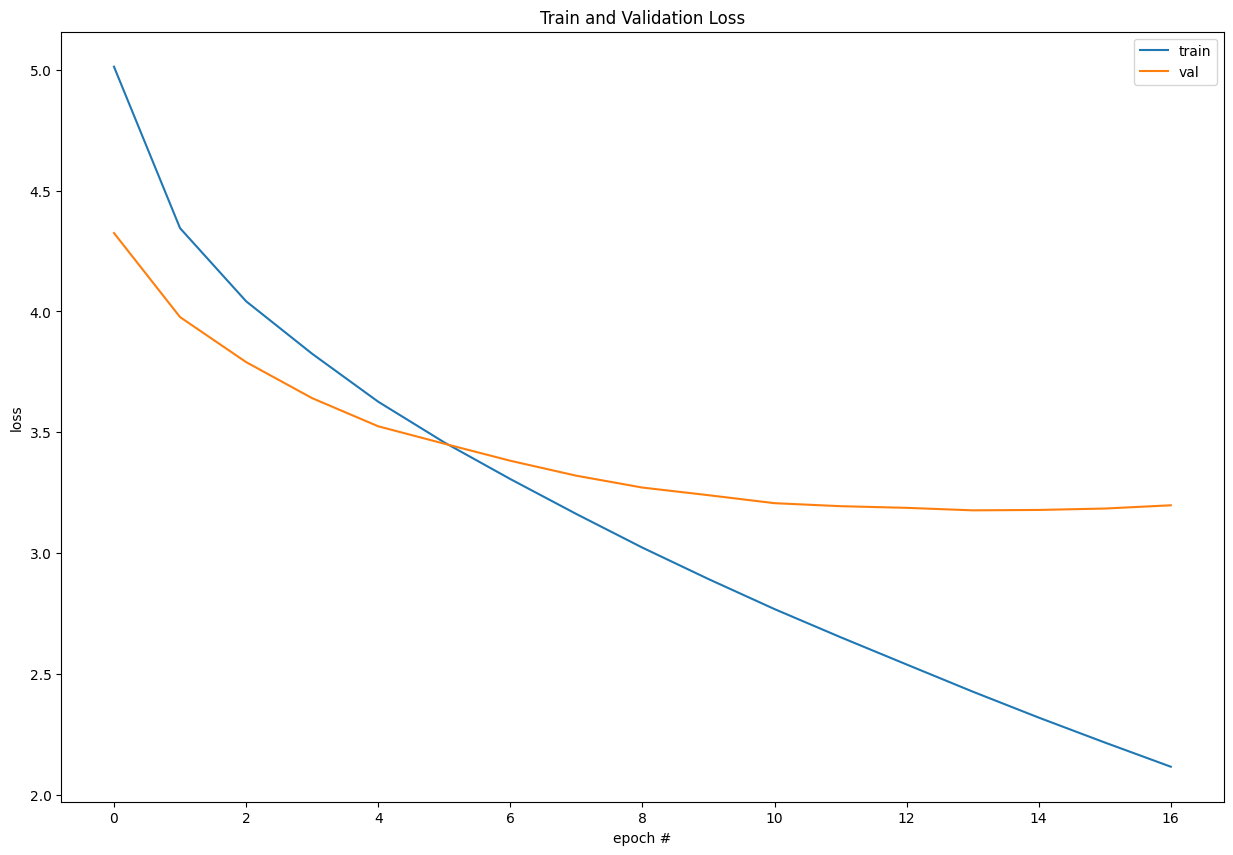

In [ ]:
# Plot the training and validation loss curves over epochs
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_en_es).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="Train and Validation Loss",
)

### Evaluating translation quality with BLEU

Loss is useful for monitoring training, but it’s not a very interpretable
metric for translation quality. To compare different models and checkpoints in a
way that roughly matches human judgment, we use **BLEU** (Bilingual Evaluation
Understudy), here via the [`sacrebleu`](https://github.com/mjpost/sacrebleu) library.

At a high level, (unigram) BLEU:

- Compares the word counts in the system output (candidate translation) to
  the word counts in one or more human reference translations.
- Uses clipped counts so that a word repeated more times than in the
  references doesn’t get extra credit.
- Aggregates these matches over the whole corpus and applies a **brevity
  penalty** so that overly short translations are penalized.
- Produces a score between 0 and 1 (or 0 and 100 in some libraries), where
  higher is better.

#### Candidate and reference formats

The helper `translate_corpus` below translates all sentences in the test set
and returns:

- `candidate_text`: the model’s translations  
  Type: `List[List[str]]`  
  Each inner list is a single translated sentence as a list of word tokens, e.g:

  ```python
  candidate_text = [
      ["this", "is", "sentence", "one"],
      ["here", "is", "another", "mighty", "fine", "translation"],
  ]
  ```

* `reference_text`: the reference translations from the dataset
  Type: `List[List[List[str]]]`

  BLEU allows multiple reference translations for each candidate, so there’s
  an extra level of nesting: for each candidate sentence, we have a list of
  possible references. For example:

  ```python
  reference_text = [
      [
          # all reference translations for the first candidate
          ["this", "is", "sentence", "one"],
          ["here", "is", "another", "translation", "for", "sentence", "one"],
      ],
      [
          # all reference translations for the second candidate
          ["here", "is", "another", "mighty", "fine", "translation"],
      ],
  ]
  ```

In our setup, we only have one reference per sentence, so for each
candidate you’ll see a list containing a single reference:

```python
reference_text[i]  # → [ [w1, w2, ..., wK] ]
```

The `print_bleu` function will:

1. Join each candidate token list into a string.
2. Rearrange the references into the format expected by `sacrebleu.corpus_bleu`.
3. Compute the corpus-level BLEU score and print it (normalized to the
   0–1 range).

Below this markdown, `translate_corpus` and `print_bleu` implement this whole
pipeline using `sacrebleu`.

In [ ]:
def translate_corpus(
    vocab: Dict[str, int],
    test_ds: TranslationDataset,
    model: Seq2Seq,
    max_steps: int = 20,
) -> Tuple[List[List[str]], List[List[List[str]]]]:
    """
    Run the model on the entire test set and collect candidate and reference
    translations in the format expected by BLEU.

    This version decodes the whole test set in a single batched call for speed.
    """
    # Invert vocab: index → token
    index_to_word = {v: k for k, v in vocab.items()}

    candidate_text: List[List[str]] = []
    reference_text: List[List[List[str]]] = []

    num_sentences = len(test_ds)

    # Build a padded source matrix for the entire test set
    src_seqs = [np.array(seq, dtype="int32") for seq in test_ds.source]  # list of [T_i]
    encoder_inputs = keras.preprocessing.sequence.pad_sequences(
        src_seqs,
        padding="post",
        value=PADDING_IDX,
    )  # [N, T_enc]

    # Run batched greedy decoding once
    generated_batch = model.generate_batch(
        encoder_inputs=tf.convert_to_tensor(encoder_inputs, dtype=tf.int32),
        max_steps=max_steps,
        eos_idx=EOS_IDX,
    ).numpy()  # [N, max_steps]

    for i in range(num_sentences):
        # ---- Candidate sentence ----
        gen_ids = generated_batch[i]  # [max_steps]

        # Optionally truncate at the first EOS to mimic the original behavior
        trimmed_ids: List[int] = []
        for idx in gen_ids:
            idx_int = int(idx)
            trimmed_ids.append(idx_int)
            if idx_int == EOS_IDX:
                break

        new_candidate_text = [index_to_word[idx] for idx in trimmed_ids]

        # ---- Reference sentence ----
        tgt_ids = np.array(test_ds.target[i], dtype="int32")
        new_reference_tokens = [index_to_word[int(idx)] for idx in tgt_ids]
        # BLEU expects a list of references per sentence
        new_reference_text = [new_reference_tokens]

        candidate_text.append(new_candidate_text)
        reference_text.append(new_reference_text)

    return candidate_text, reference_text



def print_bleu(
    lang_name: str,
    train_ds: TranslationDataset,
    test_ds: TranslationDataset,
    model: Seq2Seq,
) -> None:
    """
    Compute and print the corpus-level BLEU score using sacrebleu.

    Args:
        lang_name: Human-readable label for the language pair (for printing).
        train_ds:  Training TranslationDataset (used here for its target_vocab).
        test_ds:   TranslationDataset over the test split.
        model:     Trained Seq2Seq model to evaluate.
    """
    cand, refs = translate_corpus(train_ds.target_vocab, test_ds, model)
    # cand: [num_sentences][tokens]
    # refs: [num_sentences][num_refs][tokens]

    # 1) Candidates: join tokens into strings, one per sentence
    sys_stream = [" ".join(s) for s in cand]  # [N]

    # 2) References: arrange into [num_refs][N] for sacrebleu
    num_refs = len(refs[0])  # how many references per sentence (here, 1)
    ref_streams: List[List[str]] = []

    for j in range(num_refs):
        # For reference j, collect the j-th reference for every sentence i
        ref_streams.append(
            [" ".join(refs_i[j]) for refs_i in refs]
        )
    # ref_streams: [R][N], where R = num_refs

    # Compute BLEU with sacrebleu (returns score in [0, 100])
    bleu = sacrebleu.corpus_bleu(sys_stream, ref_streams)
    print(lang_name, bleu.score / 100.0)

In [ ]:
print_bleu("English -> Spanish", train_ds, test_ds, model_en_es)
# Example output:
# English -> Spanish 0.12619606701798783

English -> Spanish 0.2309531099640925


### Inspecting example translations (filtered and unfiltered)

BLEU gives us a single summary number, but it’s also important to look at *actual translations* to understand what the model is doing well (or badly).

The helper function `show_mixed_examples` prints a small set of English → Spanish examples from the test set in two modes:

1. **Filtered examples**  
   - We first filter out cases where the source or reference contain too many `<UNK>` tokens.
   - This gives us “cleaner” examples where the vocabulary is mostly known.
   - For each selected sentence, we print:
     - `SRC (EN)`: the English source sentence
     - `PRED(ES)`: the model’s Spanish prediction (generated with `model.generate`)
     - `REF (ES)`: the reference Spanish translation

2. **Unfiltered examples**  
   - We then sample some sentences with **no restriction** on `<UNK>` count.
   - This shows how the model behaves on more difficult or rare-word cases.

The helper `toks_from_ids` converts index sequences back into tokens, and removes padding and `<EOS>` markers so we see only “visible” words. Parameters like `max_steps`, `max_unk_filtered`, `n_filtered`, and `n_unfiltered` control how long the generated translations can be and how many examples of each type to display.


In [ ]:
def show_mixed_examples(
    train_ds: TranslationDataset,
    test_ds: TranslationDataset,
    model: Seq2Seq,
    max_steps: int = 20,
    max_unk_filtered: int = 1,
    n_filtered: int = 5,
    n_unfiltered: int = 5,
) -> None:
    """
    Print a mix of "clean" and "raw" English → Spanish translations
    from the test set.

    Args:
        train_ds:          Training TranslationDataset (used for vocab lookups).
        test_ds:           TranslationDataset over the test split.
        model:             Trained Seq2Seq model with .generate().
        max_steps:         Maximum number of decoding steps in generation.
        max_unk_filtered:  Maximum total number of <UNK> tokens allowed across
                           source and reference for an example to appear in the
                           filtered section.
        n_filtered:        Number of filtered examples to show.
        n_unfiltered:      Number of unfiltered examples to show.

    The function prints:
      - A block of "filtered" examples with few <UNK> tokens.
      - A block of "unfiltered" examples with no restrictions.
    """
    # Build index → token maps for source (English) and target (Spanish)
    src_idx2word = {v: k for k, v in train_ds.source_vocab.items()}
    tgt_idx2word = {v: k for k, v in train_ds.target_vocab.items()}

    def toks_from_ids(ids, idx2word: Dict[int, str]) -> List[str]:
        """
        Convert a 1D sequence of token indices into a list of strings,
        filtering out padding and EOS tokens.
        """
        tokens: List[str] = []
        for idx in ids:
            i = int(idx)
            if i in {PADDING_IDX, EOS_IDX}:
                continue
            tokens.append(idx2word[i])
        return tokens

    # -------- Filtered examples --------
    print(f"=== Filtered examples (max UNK = {max_unk_filtered}) ===")
    shown_filtered = 0

    for i in range(len(test_ds)):
        src_ids, tgt_ids = test_ds[i]  # each is a 1D int32 array

        src_tokens = toks_from_ids(src_ids, src_idx2word)
        ref_tokens = toks_from_ids(tgt_ids, tgt_idx2word)

        # Count unknowns in source + reference
        unk_count = src_tokens.count("<UNK>") + ref_tokens.count("<UNK>")
        if unk_count > max_unk_filtered:
            continue

        # Only generate once we know the example passes the UNK filter
        pred_ids = model.generate(
            src_ids,
            max_steps=max_steps,
            eos_idx=EOS_IDX,
        )
        pred_tokens = toks_from_ids(pred_ids, tgt_idx2word)

        print("SRC (EN):", " ".join(src_tokens))
        print("PRED(ES):", " ".join(pred_tokens))
        print("REF (ES):", " ".join(ref_tokens))
        print("-" * 60)

        shown_filtered += 1
        if shown_filtered >= n_filtered:
            break

    # -------- Unfiltered examples --------
    print("=== Unfiltered examples (no UNK limit) ===")
    shown_unfiltered = 0

    for i in range(len(test_ds)):
        src_ids, tgt_ids = test_ds[i]

        src_tokens = toks_from_ids(src_ids, src_idx2word)
        ref_tokens = toks_from_ids(tgt_ids, tgt_idx2word)

        pred_ids = model.generate(
            src_ids,
            max_steps=max_steps,
            eos_idx=EOS_IDX,
        )
        pred_tokens = toks_from_ids(pred_ids, tgt_idx2word)

        print("SRC (EN):", " ".join(src_tokens))
        print("PRED(ES):", " ".join(pred_tokens))
        print("REF (ES):", " ".join(ref_tokens))
        print("-" * 60)

        shown_unfiltered += 1
        if shown_unfiltered >= n_unfiltered:
            break

# Example usage on the English → Spanish model
show_mixed_examples(
    train_ds,
    test_ds,
    model_en_es,
    max_steps=20,
    max_unk_filtered=1,
    n_filtered=5,
    n_unfiltered=5,
)

=== Filtered examples (max UNK = 1) ===
SRC (EN): they are a key instrument for the european legislative process
PRED(ES): son una <UNK> de la unión europea para la unión europea
REF (ES): las <UNK> son un instrumento fundamental para el proceso legislativo europeo
------------------------------------------------------------
SRC (EN): you are absolutely right mr posselt
PRED(ES): tiene usted razón señor presidente
REF (ES): tiene usted toda la razón sr posselt
------------------------------------------------------------
SRC (EN): we are therefore lagging behind when it comes to innovation as well
PRED(ES): por lo tanto estamos trabajando con el parlamento europeo
REF (ES): por lo tanto también vamos a la <UNK> en los que respecta a innovación
------------------------------------------------------------
SRC (EN): we are not without ideas
PRED(ES): no estamos <UNK>
REF (ES): no carecemos de ideas
------------------------------------------------------------
SRC (EN): we are faced with an 

### Qualitative look at English → Spanish translations

These examples show the characteristic behavior of this **no-attention encoder–decoder**: it usually gets the broad Europarl “frame” and discourse stance right, but can blur or drift on the specific propositional content when everything has to be routed through a single encoder state.

* On the **filtered** examples, the model often gets the Europarl frame but blurs or distorts the core meaning:

  * `they are a key instrument for the european legislative process`
    → `son una <UNK> de la unión europea para la unión europea`
    It locks onto “Unión Europea” and a plausible noun slot, but the crucial idea of being a *key instrument* in the legislative process is largely lost.

  * `you are absolutely right mr posselt`
    → `tiene usted razón señor presidente`
    Politeness and agreement are good (`tiene usted razón`), but the addressee is generalized to the generic “señor presidente,” and the strong “absolutely” is softened.

  * `we are therefore lagging behind when it comes to innovation as well`
    → `por lo tanto estamos trabajando con el parlamento europeo`
    The connective “por lo tanto” and institutional frame are reasonable, but the specific notion of *lagging behind in innovation* is replaced by a more generic “working with the European Parliament.”

* On the more **difficult / noisy** cases (with `<UNK>` and less literal matches), the model leans heavily on generic templates and stance:

  * `we are, however, strongly opposed to this`
    → `estoy totalmente a favor de que se <UNK> en este sentido`
    Here the stance flips: “strongly opposed” becomes “totally in favor,” a classic sign that the model is following a frequent template rather than tracking the exact polarity of this sentence.

  * `we are experiencing a very <UNK> and divided <UNK>`
    → `estamos hablando de una <UNK> y <UNK>`
    And  
    `we are in a period of <UNK> <UNK> and <UNK>`
    → `estamos hablando de una <UNK> de <UNK> y <UNK>`
    In both cases, the input collapses to the high-frequency frame `estamos hablando de ...`, keeping the discourse vibe (“we are talking about something”) but losing exactly *what* is being experienced or *which* period we are in.

The model:

* Produces fluent Europarl-style sentences with reasonable grammar and discourse markers.
* Heavily relies on generic templates and global topic cues, leading to more semantic drift and stance flips than a stronger attention-based variant trained in a separate notebook.
* Lets `<UNK>` eat key nouns/verbs, and without any explicit mechanism to focus on anchor words in the source, it often loses the specific “who did what to whom” details of each sentence.


## 3. Extending to multiple source languages and the mystery language

Now that we’ve trained and inspected an English → Spanish model, we can reuse
the same architecture to probe the mystery language.

Recall that our pickled datasets contain parallel sentences for:

- Danish  
- English  
- German  
- Finnish  
- Spanish  
- `mystery`

The idea is:

- For each candidate source language (Danish, English, German, Finnish, Spanish), train a seq2seq model to translate **into** the `mystery` language.
- Compare their BLEU scores and training dynamics: if the mystery language is
  really just an encoded/codebook version of one of these languages, we expect that
  language → mystery model to perform noticeably better than the others.

To keep the setup for each language pair consistent, we use a small helper
function, `mystery_train_wrapper`, which:

1. Builds `TranslationDataset` objects for:
   - train: `<lang> → mystery`
   - validation: `<lang> → mystery`
   - test: `<lang> → mystery`
2. Shares the same source/target vocabularies across train/val/test for that pair.

For each source language, we call `mystery_train_wrapper(...)` to get the three
datasets, and then pass the train/validation datasets into `train_seq2seq(...)`,
which handles conversion to padded NumPy arrays and runs Keras `model.fit`
with early stopping.


In [ ]:
def mystery_train_wrapper(
    train_dict: Dict[str, List[List[str]]],
    val_dict: Dict[str, List[List[str]]],
    test_dict: Dict[str, List[List[str]]],
    lang: str,
):
    """
    Construct train/val/test TranslationDataset objects for a given
    source language → mystery translation task.

    Args:
        train_dict: Dictionary for the training split, mapping language name
                    to list of tokenized sentences.
        val_dict:   Dictionary for the validation split (same structure).
        test_dict:  Dictionary for the test split (same structure).
        lang:       Name of the source language (e.g., 'danish', 'english').

    Returns:
        train_ds, val_ds, test_ds:
            TranslationDataset instances for <lang> → mystery, where:
              - train_ds builds source and target vocabularies from the training
                sentences for <lang> and 'mystery'.
              - val_ds and test_ds reuse those vocabularies so that token indices
                are consistent across splits.
    """
    # Train dataset: source is <lang>, target is "mystery"; builds vocabularies.
    train_ds = TranslationDataset(
        train_dict[lang],
        train_dict["mystery"],
    )

    # Validation dataset: reuse training vocabularies for aligned indices.
    val_ds = TranslationDataset(
        val_dict[lang],
        val_dict["mystery"],
        source_vocab=train_ds.source_vocab,
        target_vocab=train_ds.target_vocab,
    )

    # Test dataset: same vocab reuse as validation.
    test_ds = TranslationDataset(
        test_dict[lang],
        test_dict["mystery"],
        source_vocab=train_ds.source_vocab,
        target_vocab=train_ds.target_vocab,
    )

    return train_ds, val_ds, test_ds

### Training mystery-language models for each candidate source language

We’re now ready to train a separate seq2seq model for each candidate
source language → `mystery`:

- Danish → mystery  
- English → mystery  
- German → mystery  
- Finnish → mystery  
- Spanish → mystery  

For each language, we:

1. Use `mystery_train_wrapper(...)` to build:
   - `<lang> → mystery` train/validation/test `TranslationDataset` objects, and
   - corresponding padded NumPy arrays:
     `(encoder_input, decoder_input, decoder_target)` for each split.
2. Call the same `train_seq2seq(...)` function we used for English → Spanish to:
   - Train the model with early stopping on validation loss.
   - Record the per-epoch train/validation losses for plotting later.

The code pattern is the same for every language: one block that prepares the
datasets and padded arrays with `mystery_train_wrapper`, followed by a call to
`train_seq2seq(...)` that returns a trained model and its loss history. Below is
the Danish example; similar cells are used for English, German, Finnish, and Spanish.

In [ ]:
%%time
# Train Danish → mystery model
train_ds_danish, val_ds_danish, test_ds_danish = mystery_train_wrapper(
    train_dict,
    val_dict,
    test_dict,
    lang="danish",
)

model_danish, losses_danish = train_seq2seq(
    train_ds_danish,
    val_ds_danish,
    hidden_size=256,
    n_epochs=20,
    patience=3,
    batch_size=32,
)

Beginning training
Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.0782 - val_loss: 4.5954
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.5529 - val_loss: 3.9796
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 4.0172 - val_loss: 3.6659
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.6968 - val_loss: 3.4396
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.4220 - val_loss: 3.2768
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.2053 - val_loss: 3.1555
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.0413 - val_loss: 3.0572
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.8475 - val_loss: 2.9788
Epoch 9/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.7209 - val_loss: 2.9181
Epoch 10/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.5984 - val_loss: 2.8660
Epoch 11/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.4816 - val_loss: 2.8235
Epoch 12/20
168/168 ━━━━━━━━━━━

<Axes: title={'center': 'Danish → Mystery: Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

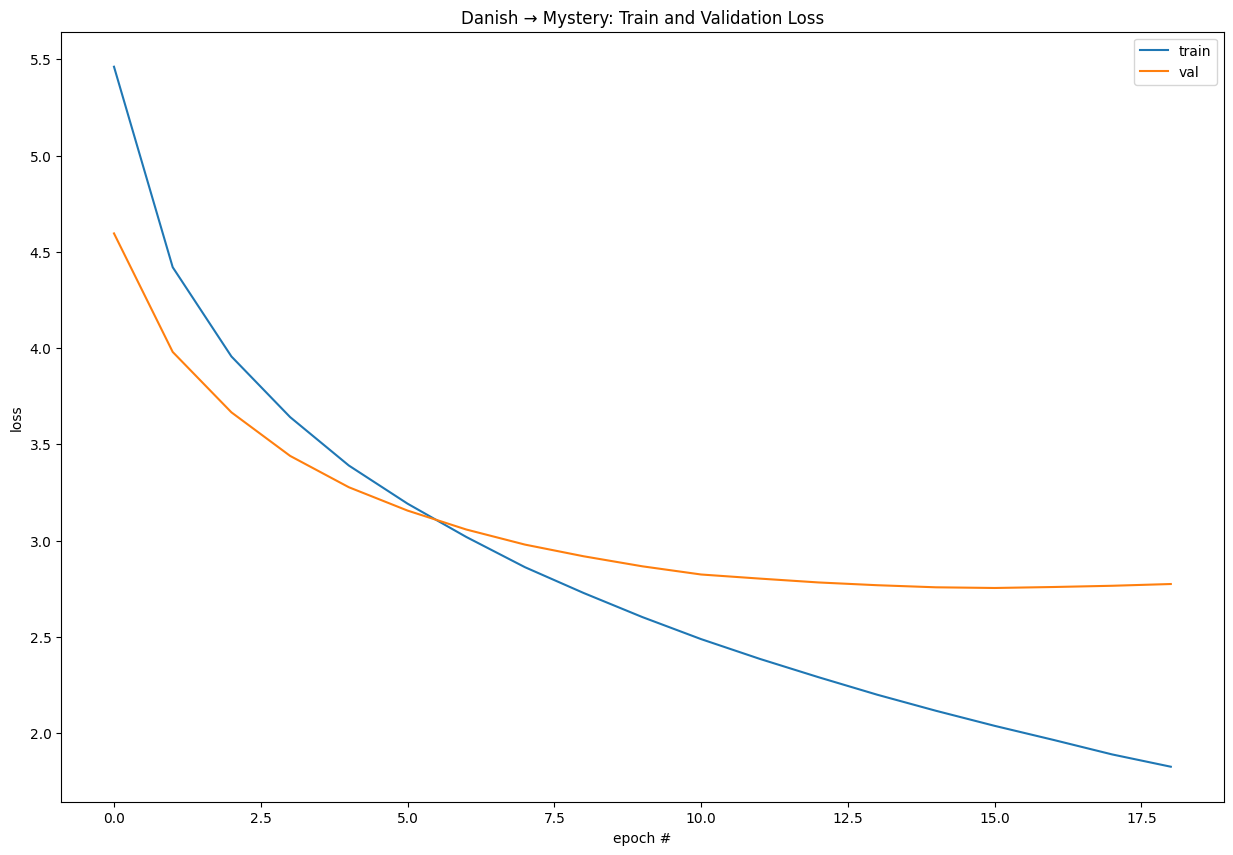

In [ ]:
# Plot Danish → mystery training and validation loss
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_danish).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="Danish → Mystery: Train and Validation Loss",
)

In [ ]:
%%time
# Train English → mystery model
train_ds_english, val_ds_english, test_ds_english = mystery_train_wrapper(
    train_dict,
    val_dict,
    test_dict,
    lang="english",
)

model_english, losses_english = train_seq2seq(
    train_ds_english,
    val_ds_english,
    hidden_size=256,
    n_epochs=20,
    patience=3,
    batch_size=32,
)

Beginning training
Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 6.0780 - val_loss: 4.6169
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.6007 - val_loss: 3.9862
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.0162 - val_loss: 3.6460
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 3.6759 - val_loss: 3.4261
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.3951 - val_loss: 3.2651
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.1798 - val_loss: 3.1327
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.9788 - val_loss: 3.0201
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.8068 - val_loss: 2.9304
Epoch 9/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.6477 - val_loss: 2.8606
Epoch 10/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.5248 - val_loss: 2.8108
Epoch 11/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.4076 - val_loss: 2.7779
Epoch 12/20
168/168 ━━━━━━━━━━━━

<Axes: title={'center': 'English → Mystery: Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

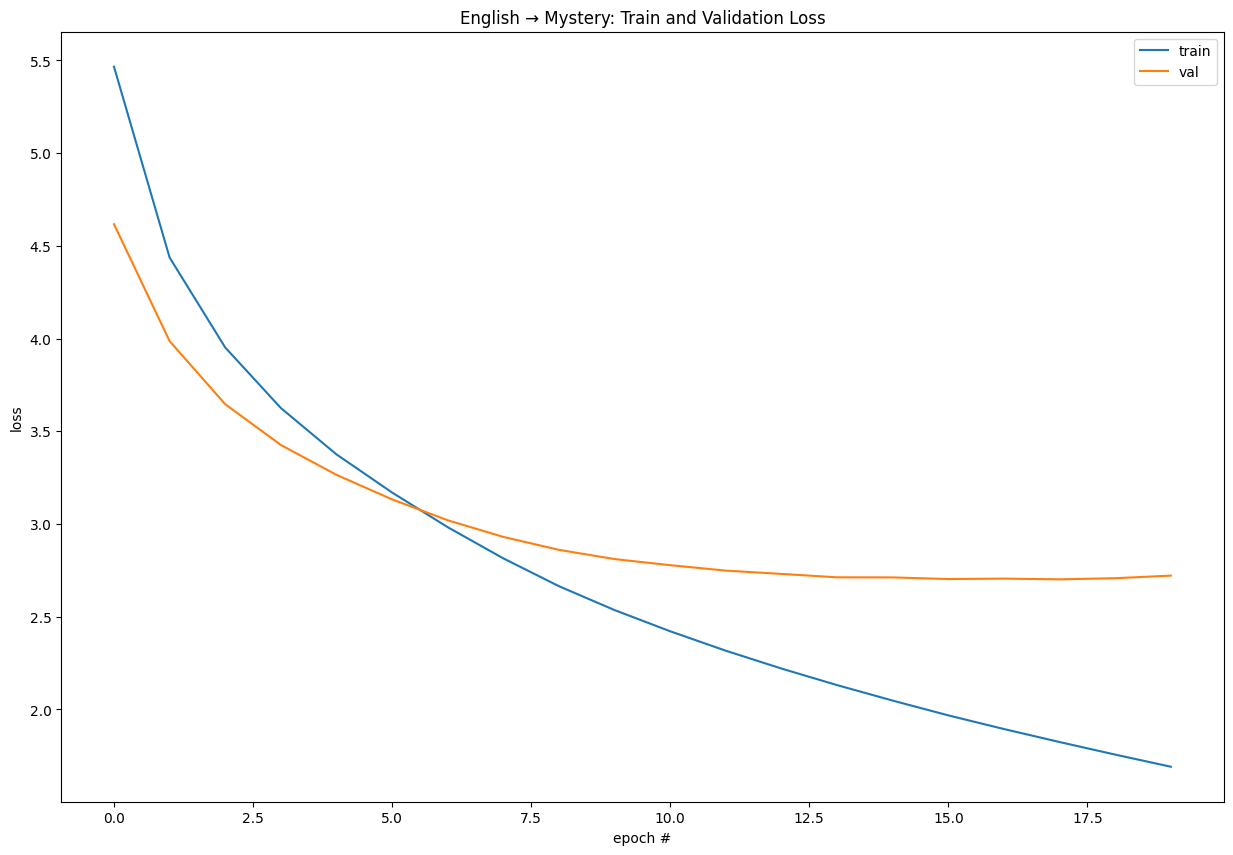

In [ ]:
# Plot English → mystery training and validation loss
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_english).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="English → Mystery: Train and Validation Loss",
)

In [ ]:
%%time
# Train German → mystery model
train_ds_german, val_ds_german, test_ds_german = mystery_train_wrapper(
    train_dict,
    val_dict,
    test_dict,
    lang="german",
)

model_german, losses_german = train_seq2seq(
    train_ds_german,
    val_ds_german,
    hidden_size=256,
    n_epochs=20,
    patience=3,
    batch_size=32,
)

Beginning training
Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.0780 - val_loss: 4.6202
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.5962 - val_loss: 4.0089
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.0514 - val_loss: 3.6716
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.6902 - val_loss: 3.4457
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.4212 - val_loss: 3.2799
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.2000 - val_loss: 3.1625
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.0183 - val_loss: 3.0645
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.8554 - val_loss: 2.9824
Epoch 9/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.7253 - val_loss: 2.9193
Epoch 10/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5979 - val_loss: 2.8716
Epoch 11/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4801 - val_loss: 2.8319
Epoch 12/20
168/168 ━━━━━━━━━━━━

<Axes: title={'center': 'German → Mystery: Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

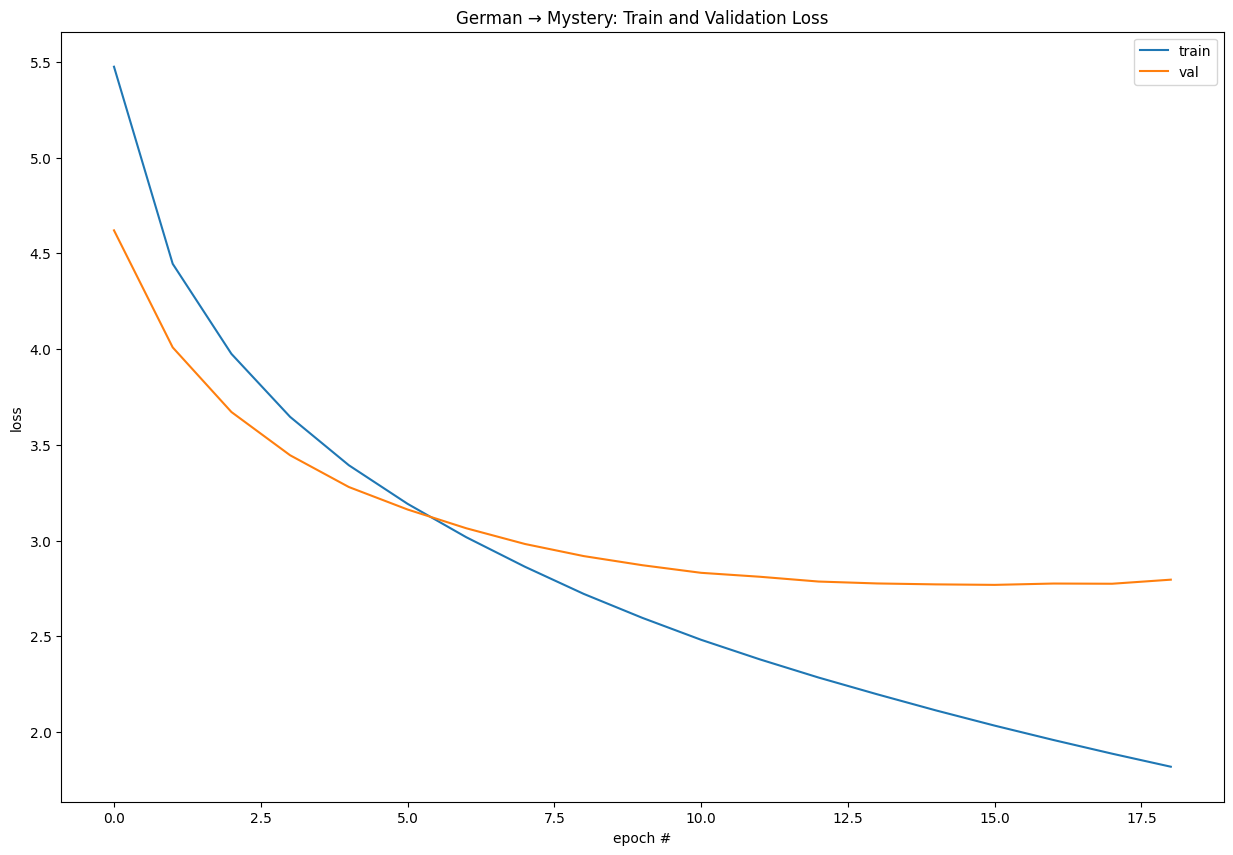

In [ ]:
# Plot German → mystery training and validation loss
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_german).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="German → Mystery: Train and Validation Loss",
)

In [ ]:
%%time
# Train Finnish → mystery model
train_ds_finnish, val_ds_finnish, test_ds_finnish = mystery_train_wrapper(
    train_dict,
    val_dict,
    test_dict,
    lang="finnish",
)

model_finnish, losses_finnish = train_seq2seq(
    train_ds_finnish,
    val_ds_finnish,
    hidden_size=256,
    n_epochs=20,
    patience=3,
    batch_size=32,
)

Beginning training
Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 6.0934 - val_loss: 4.6040
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.5661 - val_loss: 4.0091
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.0484 - val_loss: 3.6638
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.6689 - val_loss: 3.4263
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.3903 - val_loss: 3.2575
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.1732 - val_loss: 3.1307
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.9701 - val_loss: 3.0291
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.8271 - val_loss: 2.9643
Epoch 9/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.6945 - val_loss: 2.8975
Epoch 10/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5505 - val_loss: 2.8441
Epoch 11/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4259 - val_loss: 2.8072
Epoch 12/20
168/168 ━━━━━━━━━━━━

<Axes: title={'center': 'Finnish → Mystery: Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

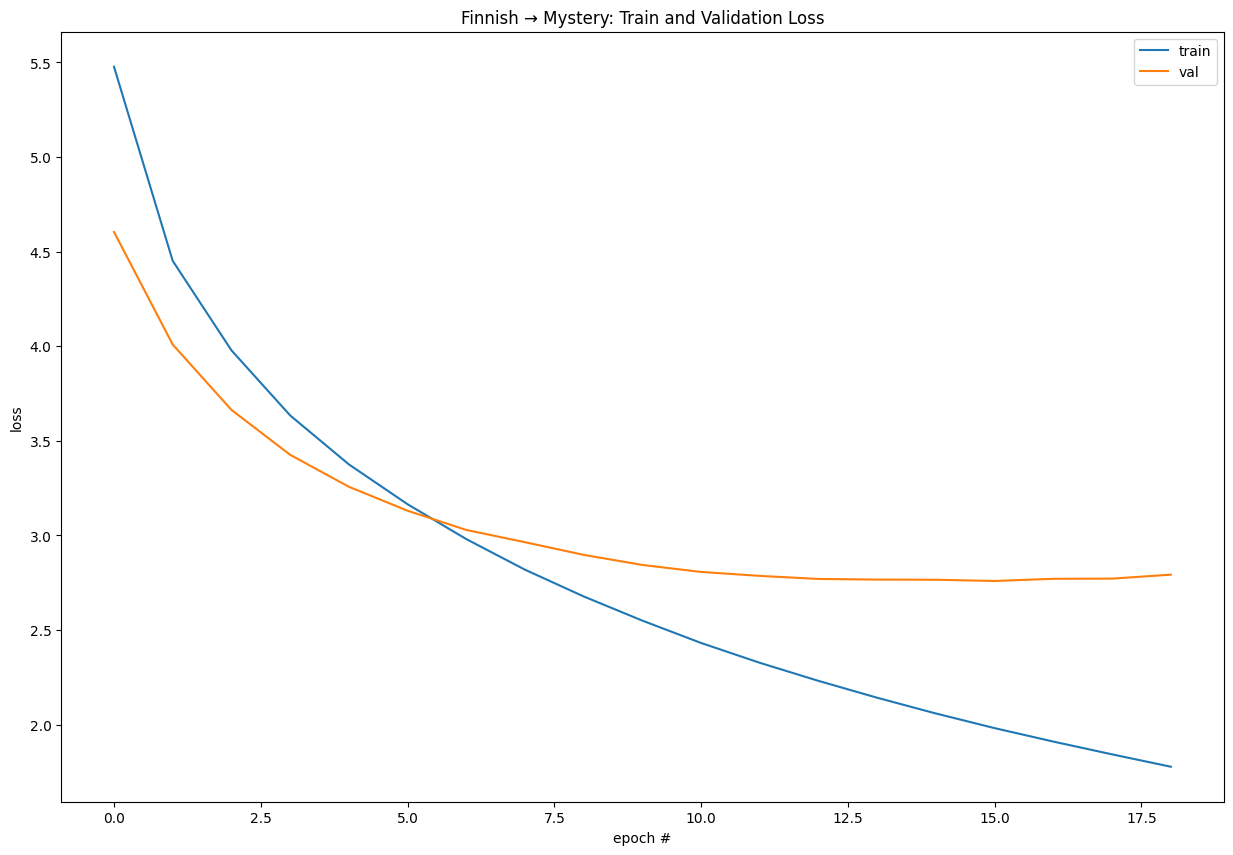

In [ ]:
# Plot Finnish → mystery training and validation loss
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_finnish).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="Finnish → Mystery: Train and Validation Loss",
)

In [ ]:
%%time
# Train Spanish → mystery model
train_ds_spanish, val_ds_spanish, test_ds_spanish = mystery_train_wrapper(
    train_dict,
    val_dict,
    test_dict,
    lang="spanish",
)

model_spanish, losses_spanish = train_seq2seq(
    train_ds_spanish,
    val_ds_spanish,
    hidden_size=256,
    n_epochs=20,
    patience=3,
    batch_size=32,
)

Beginning training
Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 6.0595 - val_loss: 4.5601
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.5419 - val_loss: 3.9582
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.9933 - val_loss: 3.6423
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.6495 - val_loss: 3.4024
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.3742 - val_loss: 3.2067
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.1269 - val_loss: 3.0264
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.8788 - val_loss: 2.8478
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.6630 - val_loss: 2.7325
Epoch 9/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4819 - val_loss: 2.6149
Epoch 10/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.3058 - val_loss: 2.5273
Epoch 11/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.1468 - val_loss: 2.4448
Epoch 12/20
168/168 ━━━━━━━━━━━━

<Axes: title={'center': 'Spanish → Mystery: Train and Validation Loss'}, xlabel='epoch #', ylabel='loss'>

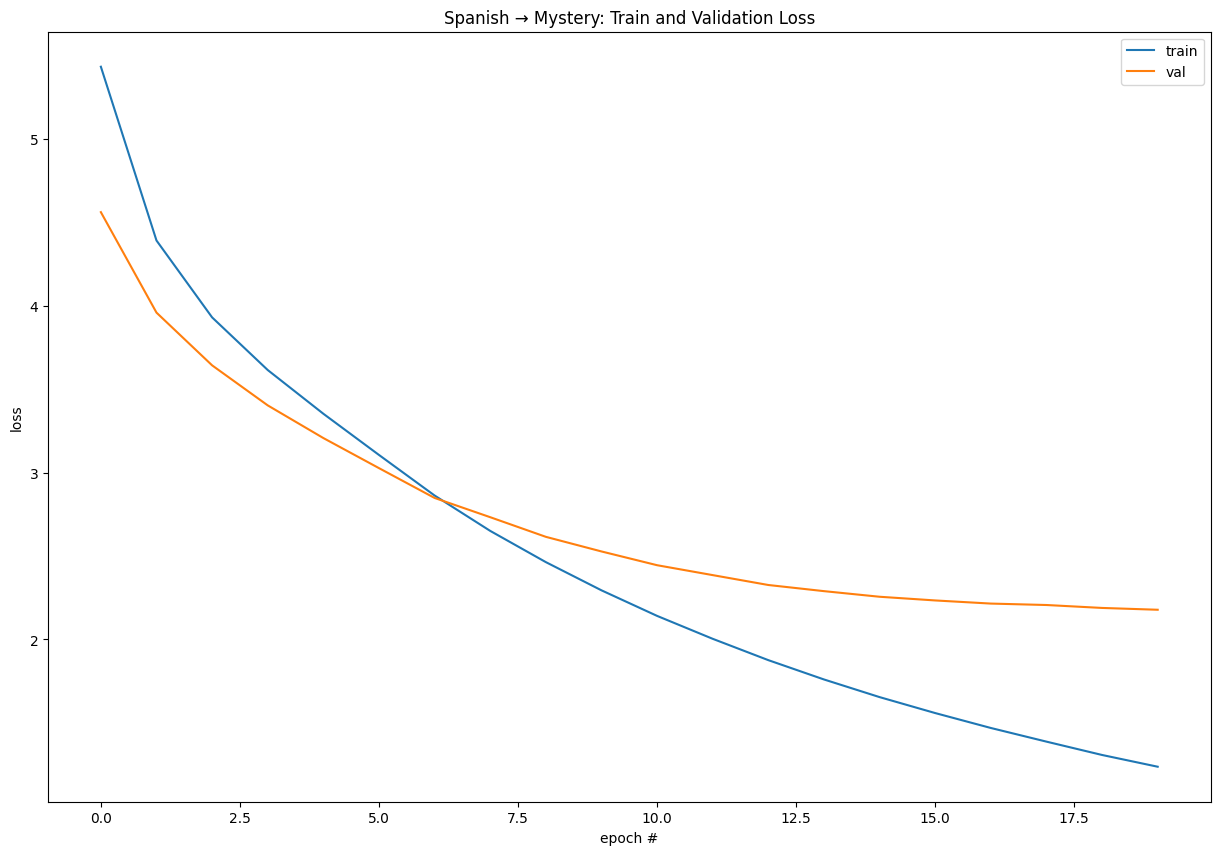

In [ ]:
# Plot Spanish → mystery training and validation loss
plt.rcParams["figure.figsize"] = [15, 10]

pd.DataFrame(losses_spanish).plot(
    xlabel="epoch #",
    ylabel="loss",
    title="Spanish → Mystery: Train and Validation Loss",
)

### Comparing BLEU scores across candidate source languages

Now that we have trained five separate models

- Danish → mystery  
- English → mystery  
- German → mystery  
- Finnish → mystery  
- Spanish → mystery  

we can evaluate all of them on their respective test sets using corpus-level BLEU.

Intuitively, if the mystery language is really an obfuscated or encoded version of one particular language, the model trained on that true source → mystery pair should achieve a noticeably higher BLEU score than the others. In our case, we expect the Spanish → mystery model to stand out if the mystery text is a codebook version of Spanish.

The cell below computes and prints the BLEU score for each candidate source language, using the same `print_bleu` helper as before, applied to each `<lang> → mystery` dataset and model.

In [ ]:
# Evaluate BLEU scores for all five source → mystery models
print_bleu("Danish → Mystery",  train_ds_danish,  test_ds_danish,  model_danish)
print_bleu("English → Mystery", train_ds_english, test_ds_english, model_english)
print_bleu("German → Mystery",  train_ds_german,  test_ds_german,  model_german)
print_bleu("Finnish → Mystery", train_ds_finnish, test_ds_finnish, model_finnish)
print_bleu("Spanish → Mystery", train_ds_spanish, test_ds_spanish, model_spanish)

Danish → Mystery 0.202678476382381
English → Mystery 0.22749981908504288
German → Mystery 0.21353563908574735
Finnish → Mystery 0.21154639493418262
Spanish → Mystery 0.3017094312510311


### The mystery language is Spanish! With a BLEU score of 0.301, around 32% higher than the next highest language English.

### What is the mystery cipher, and why is it lossy?

The `mystery` language in this notebook is not a natural language at all, but a codebook cipher applied to Spanish:

- Each Spanish word type is assigned a random “code” string.
- That code can consist of one or more whitespace-separated tokens (e.g., a single token like `qdy` or a multi-token sequence like `a bism`).
- Sentences are formed by replacing each Spanish word with its corresponding code sequence.

At first glance, this looks like a reversible substitution: if we knew the full codebook, we could just invert the mapping. In practice, several design choices in the cipher make perfect recovery impossible, even with access to the entire corpus.

#### 1. Spaces and segmentation ambiguity

Because codes can span multiple tokens and are separated by spaces, the decoder faces a segmentation problem:

- Some codes are single tokens, others are multi-token phrases.
- Worse, a valid code can be the prefix of another valid code, e.g.  
  `a` is a complete code, but `a bism` is also a complete code.

When you scan a mystery sentence from left to right, you must decide whether `a` alone is a code, or whether you should group `a bism` as a longer code. There are hundreds of such prefix overlaps. Any simple “greedy” decoding that always takes the shortest or longest match will make systematic mistakes, and even a smart decoder can’t always disambiguate purely from local context.

So the spaces themselves are part of the cipher: they don’t cleanly separate words, they separate *code tokens*, and those tokens don’t uniquely specify segmentation.

#### 2. Missing entries in the effective codebook

Some Spanish words are so rare, or so tightly bound to others, that the data never gives us enough information to distinguish them:

- Certain rare words only ever appear in a fixed collocation (e.g., word A and word B always appear together in the same sentence and never separately).
- On the mystery side, the corresponding code sequence is always seen as a single chunk; we never see A’s code or B’s code in isolation.

Even with perfect logical “Sudoku-style” elimination, we can get stuck in logical deadlocks: there are multiple assignments of codes to words that are consistent with all observed sentences. In those cases, the codebook cannot be uniquely completed from data alone, so some entries remain effectively undetermined.

#### 3. Collisions: different words, same code

The most fundamental problem is that the cipher is not injective:

- In the corpus, we can find explicit collisions, where the *same* mystery code string is aligned to two different Spanish words in different sentences.
- For example (from the analysis notebook), a single code token `q` appears aligned once to *opongo* and once to *responsable*.

This is genuine **information loss**: if both sentences appear as `q` on the mystery side, there is no way—purely from the ciphered text—to know whether the intended word was *opongo* or *responsable* in any new sentence. Any decoder must pick one (usually the more frequent), and will be wrong whenever the rarer word was intended.

#### Putting it together: a lossy code

These three issues interact:

- **Segmentation ambiguity** from multi-token codes and prefix overlaps.
- **Missing or underdetermined entries** for rare / collocated words.
- **True collisions**, where distinct Spanish words share the same code.

Even with a very strong hybrid solver (statistics + logical elimination) and access to all train/val/test data, you can push the recoverable portion of the codebook only to about 96%. The remaining cases require guessing based on context or frequency, not pure inversion of the cipher.

In other words, the mystery cipher is *lossy by design*: it does not preserve enough information for 100% exact reconstruction of the original Spanish text. This explains why, even though Spanish → mystery is clearly the “right” pairing, our seq2seq model’s BLEU score can never reach 1.0. The underlying signal itself has been irreversibly compressed and blurred by the codebook.


### Comparing training dynamics across language pairs

To get a side-by-side view of how each language pair behaves during training, we can plot the train and validation loss curves for all five source → mystery models in a single grid.

A few patterns are worth noticing:

- For Danish, English, German, and Finnish, the validation loss drops at first and then flattens out around a relatively high value, even as the training loss continues to decrease. This suggests the models are fitting their training data but have limited ability to generalize to the validation set.
- In contrast, the Spanish → mystery model shows both training and validation loss dropping much further and stabilizing at clearly lower values than the other languages.
- The gap between train and validation curves for Spanish is also smaller and more stable, which is what we’d expect when the source language is genuinely well aligned with the mystery language.

Taken together, these training histories already hint that Spanish is the best match for the mystery language, even without looking at BLEU scores.


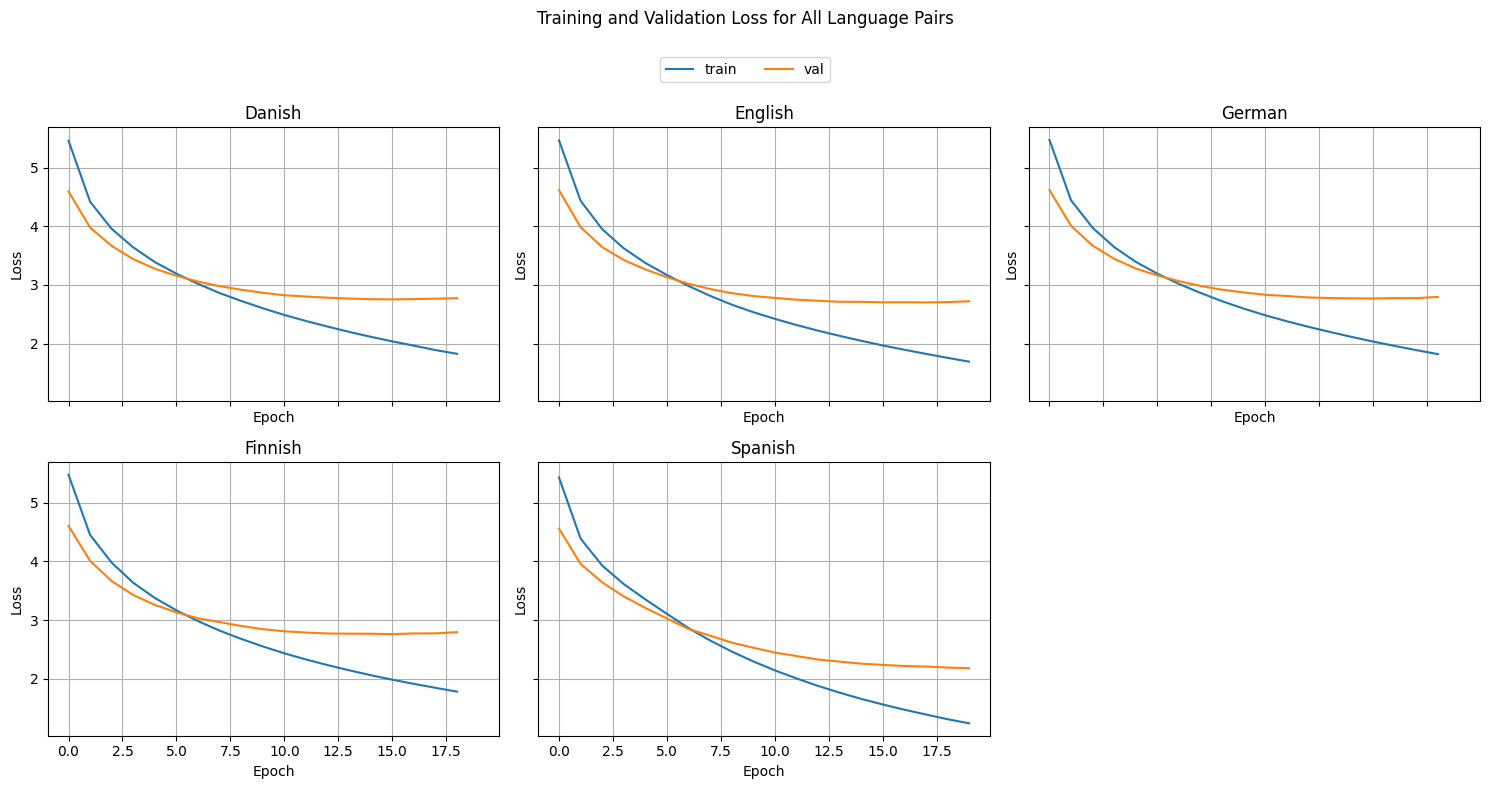

In [ ]:
# Compare all 5 language training histories visually in a 2x3 grid
histories = {
    "Danish":  losses_danish,
    "English": losses_english,
    "German":  losses_german,
    "Finnish": losses_finnish,
    "Spanish": losses_spanish,
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (lang, hist) in zip(axes, histories.items()):
    df = pd.DataFrame(hist)  # expects keys "train" and "val"
    ax.plot(df.index, df["train"], label="train")
    ax.plot(df.index, df["val"],   label="val")
    ax.set_title(lang)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)

# Hide any unused subplot (since we only have 5 languages)
if len(histories) < len(axes):
    for j in range(len(histories), len(axes)):
        fig.delaxes(axes[j])

# Layout: leave space at top for title + legend
fig.tight_layout(rect=[0, 0, 1, 0.88])

# Shared title
fig.suptitle("Training and Validation Loss for All Language Pairs", y=0.98)

# Shared legend just under the title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           ncol=2,
           bbox_to_anchor=(0.5, 0.93))

plt.show()

### Why does Spanish → mystery still get the best BLEU?

At this point we know two things:

1. The mystery language is a codebook cipher applied to Spanish.
2. The cipher is lossy: it has segmentation ambiguity, missing or underdetermined entries, and collisions where multiple Spanish words share the same code.

So why does the Spanish → mystery model still achieve a much higher BLEU score than Danish/German/Finnish/English → mystery?

There are a few key reasons.

1. **Forward mapping is consistent, even if inverse mapping is not**

   The codebook is problematic when you try to go from mystery back to Spanish. But in the *forward* direction, Spanish → mystery, the mapping is perfectly well defined:

   - Each Spanish word has a fixed code sequence on the mystery side.
   - Collisions mean that two Spanish words share the same code, but they do not create ambiguity when going forward: both words just map to that same output.

   From the model’s perspective, Spanish → mystery is “just” learning a strange but consistent target language. The training data always shows the same Spanish input aligned to the same mystery output, so the model can approximate that mapping quite well.

2. **Other languages must implicitly learn two mappings at once**

   For a non-Spanish source language (say Danish), the underlying generative story is closer to:

   > Danish → Spanish (human translation) → cipher(Spanish) = mystery

   But the model only sees:

   > Danish input → mystery output

   To succeed, a Danish → mystery model has to internally approximate both parts of the pipeline:

   - A proper translation from Danish into (something like) Spanish.
   - The exotic Spanish → code mapping on top of that.

   That is strictly harder than learning Spanish → code directly. Any errors in the implicit “Danish → Spanish” step show up as wrong codes on the mystery side, dragging BLEU down.

3. **Word order and structure are already aligned for Spanish**

   The codebook was built on Spanish sentences, so:

   - Word order, morphology, and sentence length of the mystery text are closely tied to Spanish.
   - For Spanish → mystery, the model can often stay near monotonic: source and target positions roughly line up.

   For other languages, the model has to deal with extra reordering and structural differences before it can even try to match the code tokens. That extra complexity again lowers BLEU.

4. **Lossiness caps the ceiling but not the ranking**

   The lossy parts of the cipher (collisions, ambiguous segmentations, rare words) hurt *every* model equally in the sense that even a perfect Spanish → mystery system cannot reach BLEU = 1.0:

   - Whenever two Spanish words share the same code, no model can produce outputs that uniquely preserve the original choice.
   - Ambiguous multi-token codes and underdetermined entries create irreducible uncertainty in the target sequences.

   This effectively lowers the maximum achievable BLEU for the “correct” language pair, but it does not give any advantage to the *wrong* language pairs. Spanish → mystery is still the one that can best match the observed code sequences; the others are fighting both the normal translation problem and the weirdness of the cipher.

The cipher being lossy explains why Spanish → mystery cannot achieve very high absolute BLEU, but the mapping is still far easier to learn from Spanish than from Danish, English, German, or Finnish. That is why Spanish → mystery stands out clearly in both the loss curves and the BLEU scores, even though perfect reconstruction of the original Spanish is provably impossible.
